In [ ]:
# Data exploration
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('creditcard.csv')

# Basic information
print(df.head())
print(df.info())
print(df.describe())
print(f"Dataset Shape: {df.shape}")
print(f"Fraud cases: {df['Class'].sum()}")
print(f"Fraud percentage: {df['Class'].sum()/len(df)*100:.3f}%")

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

------------------------------------------------------------
DATASET OVERVIEW
------------------------------------------------------------
Shape: (284807, 31)

Column names:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Data types:
float64    30
int64       1
Name: count, dtype: int64

Memory usage: 67.36 MB

------------------------------------------------------------
CLASS DISTRIBUTION
------------------------------------------------------------
Class
0    284315
1       492
Name: count, dtype: int64

Fraud percentage: 0.1727%
Imbalance ratio: 1:578

------------------------------------------------------------
MISSING VALUES
------------------------------------------------------------
No missing values!

------------------------------------------------------------
STATISTICAL SUMMARY
---------------------------------

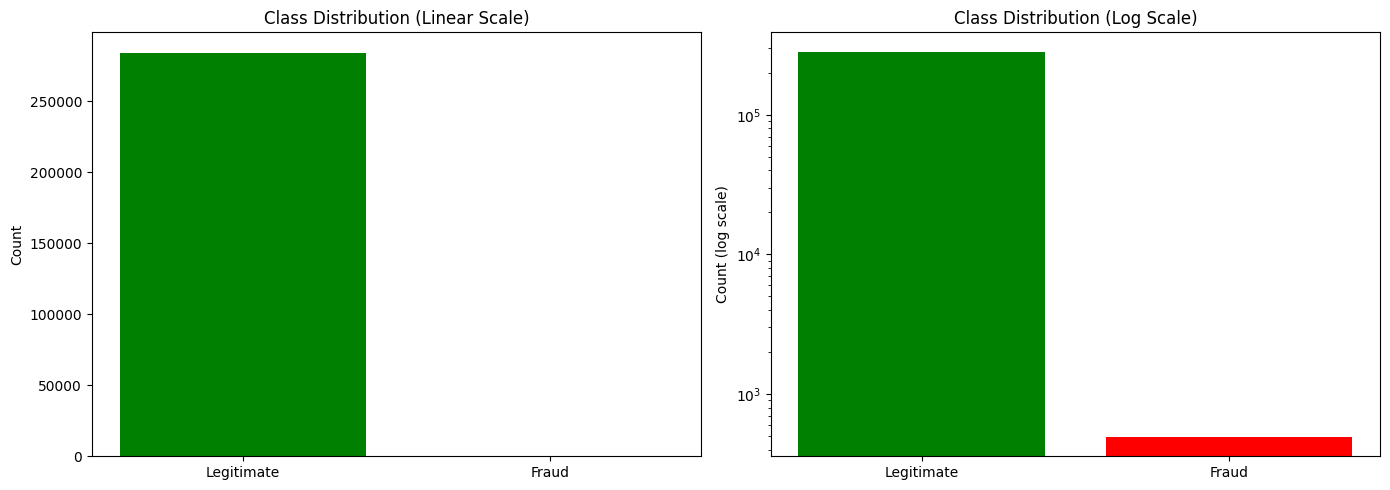

/tmp/ipykernel_1905/2441250334.py:85: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([legit_amount, fraud_amount],


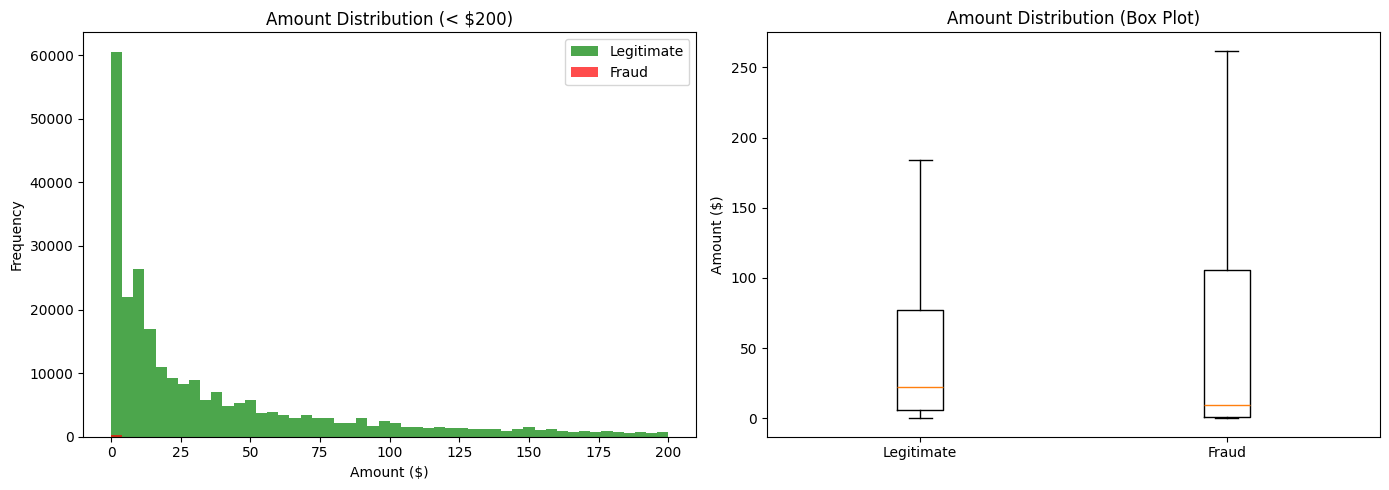

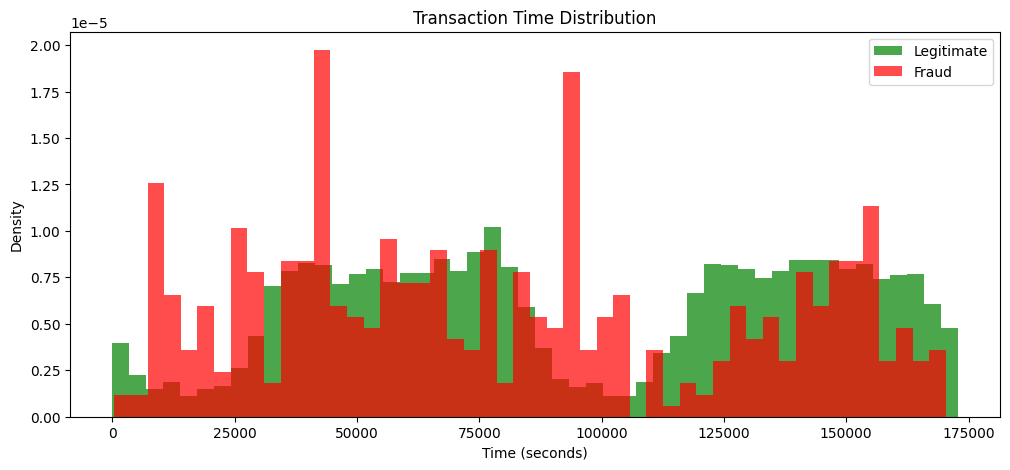

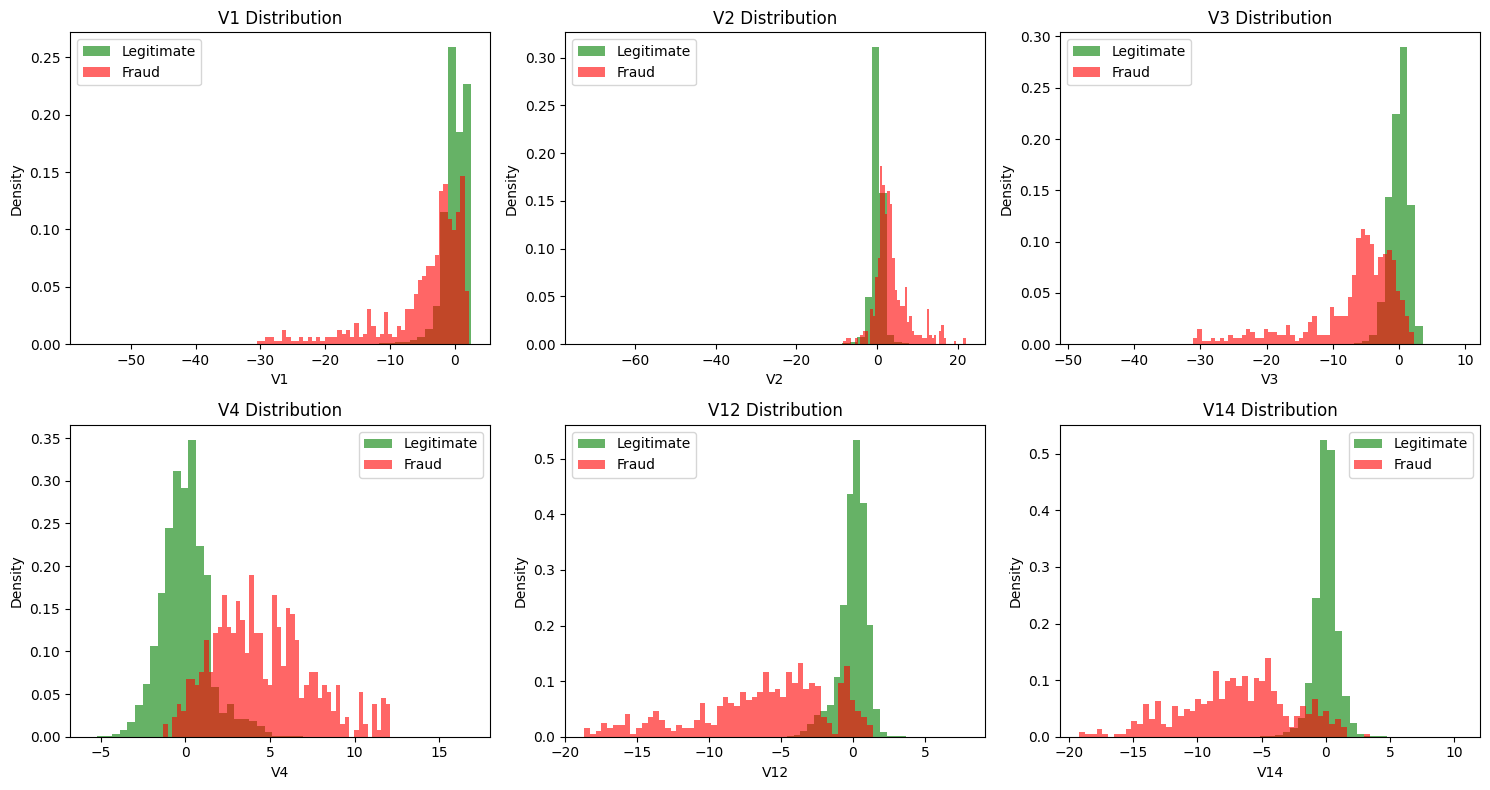

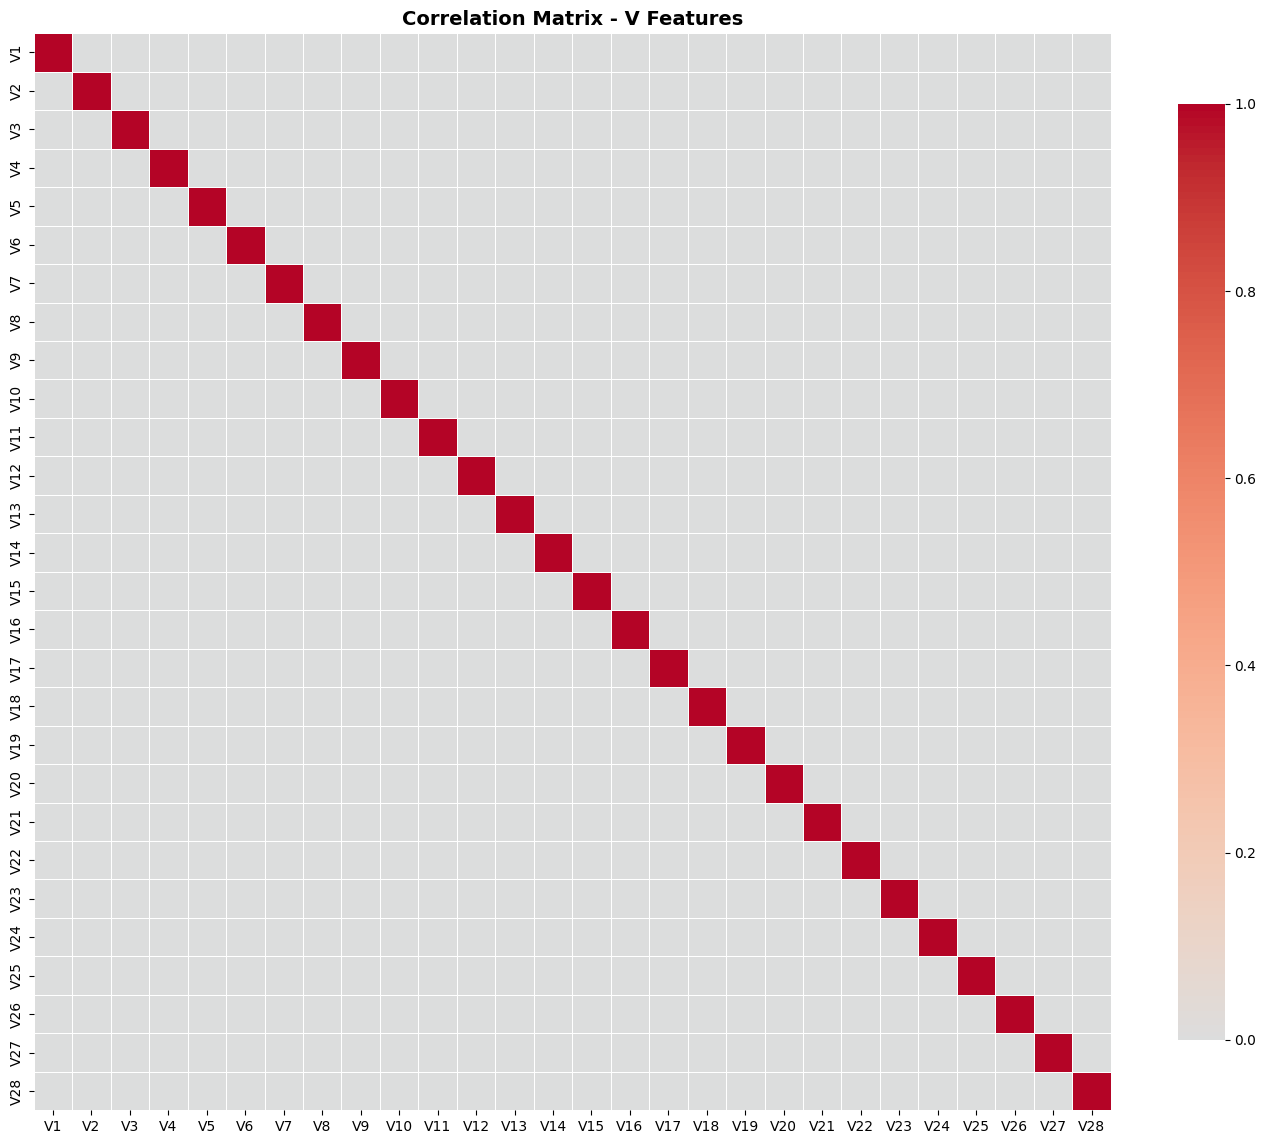

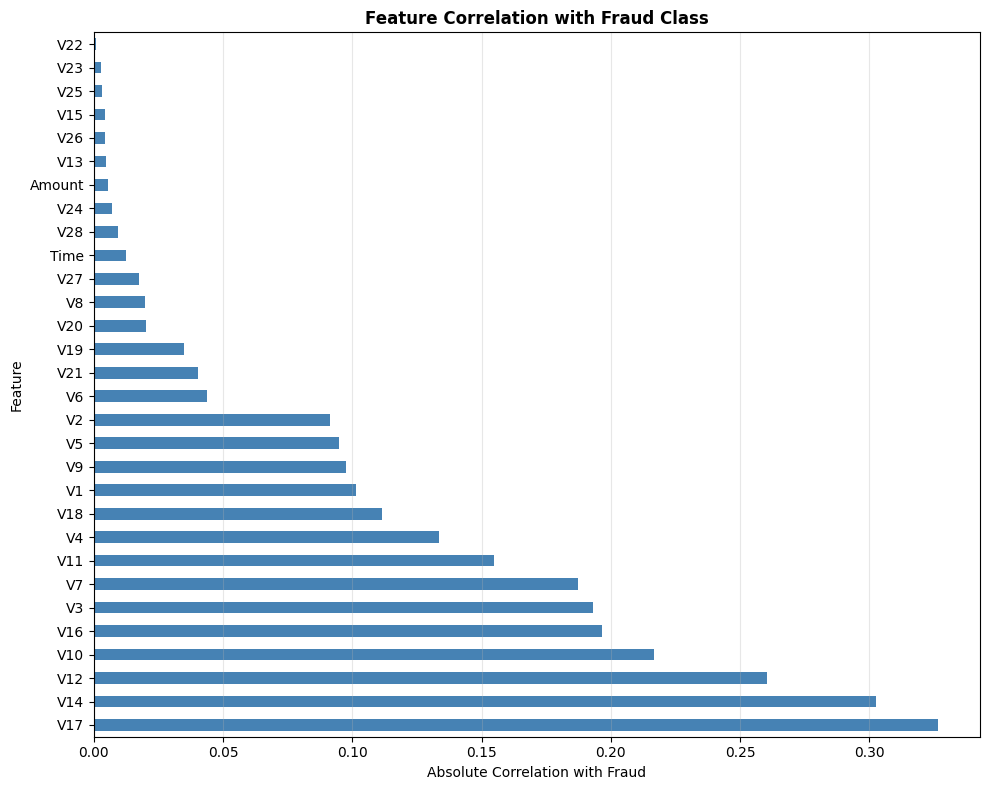


------------------------------------------------------------
TOP 10 MOST CORRELATED FEATURES WITH FRAUD
------------------------------------------------------------
V17    0.326481
V14    0.302544
V12    0.260593
V10    0.216883
V16    0.196539
V3     0.192961
V7     0.187257
V11    0.154876
V4     0.133447
V18    0.111485
dtype: float64


In [ ]:
# Data exploration 2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('creditcard.csv')

print("-" * 60)
print("DATASET OVERVIEW")
print("-" * 60)
print(f"Shape: {df.shape}")
print(f"\nColumn names:\n{df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes.value_counts()}")
print(f"\nMemory usage: {df.memory_usage().sum() / 1024**2:.2f} MB")

print("\n" + "-" * 60)
print("CLASS DISTRIBUTION")
print("-" * 60)
class_counts = df['Class'].value_counts()
print(class_counts)
print(f"\nFraud percentage: {class_counts[1]/len(df)*100:.4f}%")
print(f"Imbalance ratio: 1:{class_counts[0]/class_counts[1]:.0f}")

print("\n" + "-" * 60)
print("MISSING VALUES")
print("-" * 60)
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values!")

print("\n" + "-" * 60)
print("STATISTICAL SUMMARY")
print("-" * 60)
print("\nLegitimate Transactions:")
print(df[df['Class'] == 0][['Time', 'Amount']].describe())

print("\nFraudulent Transactions:")
print(df[df['Class'] == 1][['Time', 'Amount']].describe())

print("\n" + "-" * 60)
print("AMOUNT COMPARISON")
print("-" * 60)
legit_amount = df[df['Class'] == 0]['Amount']
fraud_amount = df[df['Class'] == 1]['Amount']

print(f"Legitimate - Mean: ${legit_amount.mean():.2f}, Median: ${legit_amount.median():.2f}")
print(f"Fraud      - Mean: ${fraud_amount.mean():.2f}, Median: ${fraud_amount.median():.2f}")
print(f"\nMedian difference: ${legit_amount.median() - fraud_amount.median():.2f}")

# VISUALIZATIONS

# 1. Class Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(['Legitimate', 'Fraud'], class_counts.values, color=['green', 'red'])
axes[0].set_ylabel('Count')
axes[0].set_title('Class Distribution (Linear Scale)')
axes[0].set_yscale('linear')

axes[1].bar(['Legitimate', 'Fraud'], class_counts.values, color=['green', 'red'])
axes[1].set_ylabel('Count (log scale)')
axes[1].set_title('Class Distribution (Log Scale)')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

# 2. Amount Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(legit_amount[legit_amount < 200], bins=50, alpha=0.7,
            label='Legitimate', color='green')
axes[0].hist(fraud_amount[fraud_amount < 200], bins=50, alpha=0.7,
            label='Fraud', color='red')
axes[0].set_xlabel('Amount ($)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Amount Distribution (< $200)')
axes[0].legend()

axes[1].boxplot([legit_amount, fraud_amount],
               labels=['Legitimate', 'Fraud'],
               showfliers=False)
axes[1].set_ylabel('Amount ($)')
axes[1].set_title('Amount Distribution (Box Plot)')

plt.tight_layout()
plt.show()

# 3. Time Distribution
fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(df[df['Class'] == 0]['Time'], bins=50, alpha=0.7,
       label='Legitimate', color='green', density=True)
ax.hist(df[df['Class'] == 1]['Time'], bins=50, alpha=0.7,
       label='Fraud', color='red', density=True)
ax.set_xlabel('Time (seconds)')
ax.set_ylabel('Density')
ax.set_title('Transaction Time Distribution')
ax.legend()
plt.show()

# 4. V Features Distribution (first 6)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
v_features = ['V1', 'V2', 'V3', 'V4', 'V12', 'V14']

for idx, feature in enumerate(v_features):
    ax = axes[idx // 3, idx % 3]

    ax.hist(df[df['Class'] == 0][feature], bins=50, alpha=0.6,
           label='Legitimate', color='green', density=True)
    ax.hist(df[df['Class'] == 1][feature], bins=50, alpha=0.6,
           label='Fraud', color='red', density=True)
    ax.set_xlabel(feature)
    ax.set_ylabel('Density')
    ax.set_title(f'{feature} Distribution')
    ax.legend()

plt.tight_layout()
plt.show()

# 5. Correlation Heatmap (V features only)
v_cols = [f'V{i}' for i in range(1, 29)]
correlation_matrix = df[v_cols].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, cmap='coolwarm', center=0,
           square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - V Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 6. Feature Importance (correlation with Class)
feature_correlations = df[v_cols + ['Amount', 'Time']].corrwith(df['Class']).abs().sort_values(ascending=False)

plt.figure(figsize=(10, 8))
feature_correlations.plot(kind='barh', color='steelblue')
plt.xlabel('Absolute Correlation with Fraud')
plt.ylabel('Feature')
plt.title('Feature Correlation with Fraud Class', fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "-" * 60)
print("TOP 10 MOST CORRELATED FEATURES WITH FRAUD")
print("-" * 60)
print(feature_correlations.head(10))

In [ ]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())

# Check for duplicates
print(f"\nDuplicate rows: {df.duplicated().sum()}")

# Remove duplicates if any
df = df.drop_duplicates()

Missing values:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Duplicate rows: 0


In [ ]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler, RobustScaler

# The Amount feature needs scaling (V1-V28 are already scaled via PCA)
# Time might also need transformation

# Scale Amount
scaler = RobustScaler()  # Robust to outliers
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])

# Transform Time to hour of day (cyclical feature)
df['Time_hour'] = (df['Time'] / 3600) % 24
df['Time_hour_sin'] = np.sin(2 * np.pi * df['Time_hour'] / 24)
df['Time_hour_cos'] = np.cos(2 * np.pi * df['Time_hour'] / 24)

# Drop original Time and Amount
df_processed = df.drop(['Time', 'Amount', 'Time_hour'], axis=1)

In [ ]:
# Data splitting
from sklearn.model_selection import train_test_split

# Separate features and target
X = df_processed.drop('Class', axis=1)
y = df_processed['Class']

# First split: 80% train+val, 20% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Second split: 75% train, 25% validation (of the 80%)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print(f"Training set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set: {X_test.shape}")

print(f"\nFraud in training: {y_train.sum()} ({y_train.sum()/len(y_train)*100:.3f}%)")
print(f"Fraud in validation: {y_val.sum()} ({y_val.sum()/len(y_val)*100:.3f}%)")
print(f"Fraud in test: {y_test.sum()} ({y_test.sum()/len(y_test)*100:.3f}%)")

Training set: (170235, 31)
Validation set: (56745, 31)
Test set: (56746, 31)

Fraud in training: 284 (0.167%)
Fraud in validation: 94 (0.166%)
Fraud in test: 95 (0.167%)


In [ ]:
# Model 1: Baseline Deep Neural Network (DNN), Architecture
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from sklearn.utils.class_weight import compute_class_weight

# Calculate class weights
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print(f"Class weights: {class_weight_dict}")

# Build DNN Model
def build_dnn_model(input_dim):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),

        layers.Dense(64, activation='relu', name='dense_1'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(32, activation='relu', name='dense_2'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(16, activation='relu', name='dense_3'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        layers.Dense(8, activation='relu', name='dense_4'),

        layers.Dense(1, activation='sigmoid', name='output')
    ])

    return model

# Create model
dnn_model = build_dnn_model(X_train.shape[1])

# Compile with custom metrics
dnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
        keras.metrics.AUC(name='auc'),
        keras.metrics.AUC(curve='PR', name='pr_auc')
    ]
)

dnn_model.summary()

Class weights: {0: np.float64(0.5008355349483087), 1: np.float64(299.7095070422535)}


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 64)             │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,249 (20.50 KB)

 Trainable params: 5,025 (19.63 KB)

 Non-trainable params: 224 (896.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Callbacks
early_stopping = EarlyStopping(
    monitor='val_pr_auc',
    patience=15,
    restore_best_weights=True,
    mode='max'
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_dnn_model.h5',
    monitor='val_pr_auc',
    save_best_only=True,
    mode='max'
)

# Train
history_dnn = dnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=2048,
    class_weight=class_weight_dict,
    callbacks=[early_stopping, reduce_lr, checkpoint],
    verbose=1
)

Epoch 1/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.9058 - auc: 0.5630 - loss: 1.2176 - pr_auc: 0.0437 - precision: 0.0054 - recall: 0.3055

84/84 ━━━━━━━━━━━━━━━━━━━━ 17s 111ms/step - accuracy: 0.8907 - auc: 0.7111 - loss: 0.7889 - pr_auc: 0.0937 - precision: 0.0074 - recall: 0.4859 - val_accuracy: 0.9062 - val_auc: 0.9572 - val_loss: 0.4712 - val_pr_auc: 0.4811 - val_precision: 0.0161 - val_recall: 0.9255 - learning_rate: 0.0010
Epoch 2/100
75/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8676 - auc: 0.9039 - loss: 0.4300 - pr_auc: 0.2510 - precision: 0.0102 - recall: 0.7762

84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8614 - auc: 0.9020 - loss: 0.4090 - pr_auc: 0.2516 - precision: 0.0096 - recall: 0.8028 - val_accuracy: 0.9311 - val_auc: 0.9686 - val_loss: 0.3141 - val_pr_auc: 0.6461 - val_precision: 0.0211 - val_recall: 0.8936 - learning_rate: 0.0010
Epoch 3/100
81/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8643 - auc: 0.9468 - loss: 0.3232 - pr_auc: 0.3205 - precision: 0.0109 - recall: 0.8782

84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8708 - auc: 0.9418 - loss: 0.3233 - pr_auc: 0.3168 - precision: 0.0111 - recall: 0.8697 - val_accuracy: 0.9377 - val_auc: 0.9701 - val_loss: 0.2333 - val_pr_auc: 0.6807 - val_precision: 0.0235 - val_recall: 0.9043 - learning_rate: 0.0010
Epoch 4/100
71/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8834 - auc: 0.9687 - loss: 0.2551 - pr_auc: 0.3733 - precision: 0.0126 - recall: 0.8943

84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8915 - auc: 0.9668 - loss: 0.2494 - pr_auc: 0.3563 - precision: 0.0139 - recall: 0.9120 - val_accuracy: 0.9459 - val_auc: 0.9715 - val_loss: 0.1825 - val_pr_auc: 0.7106 - val_precision: 0.0270 - val_recall: 0.9043 - learning_rate: 0.0010
Epoch 5/100
71/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9053 - auc: 0.9655 - loss: 0.2498 - pr_auc: 0.3776 - precision: 0.0166 - recall: 0.8928

84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9105 - auc: 0.9652 - loss: 0.2410 - pr_auc: 0.3525 - precision: 0.0165 - recall: 0.8979 - val_accuracy: 0.9524 - val_auc: 0.9720 - val_loss: 0.1539 - val_pr_auc: 0.7162 - val_precision: 0.0306 - val_recall: 0.9043 - learning_rate: 0.0010
Epoch 6/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9184 - auc: 0.9693 - loss: 0.2199 - pr_auc: 0.3532 - precision: 0.0183 - recall: 0.9120 - val_accuracy: 0.9523 - val_auc: 0.9726 - val_loss: 0.1452 - val_pr_auc: 0.6735 - val_precision: 0.0309 - val_recall: 0.9149 - learning_rate: 0.0010
Epoch 7/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9262 - auc: 0.9768 - loss: 0.1921 - pr_auc: 0.3980 - precision: 0.0205 - recall: 0.9225 - val_accuracy: 0.9549 - val_auc: 0.9728 - val_loss: 0.1309 - val_pr_auc: 0.6727 - val_precision: 0.0326 - val_recall: 0.9149 - learning_rate: 0.0010
Epoch 8/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9330 - auc: 0.9774 - loss: 0.1868 - pr

In [ ]:
# Autoencoder Architecture
# Autoencoder - Train ONLY on legitimate transactions
X_train_normal = X_train[y_train == 0]
X_val_normal = X_val[y_val == 0]

def build_autoencoder(input_dim):
    # Encoder
    encoder_input = layers.Input(shape=(input_dim,))
    encoded = layers.Dense(24, activation='relu')(encoder_input)
    encoded = layers.BatchNormalization()(encoded)
    encoded = layers.Dropout(0.2)(encoded)
    encoded = layers.Dense(16, activation='relu')(encoded)
    encoded = layers.BatchNormalization()(encoded)
    encoded = layers.Dense(8, activation='relu', name='bottleneck')(encoded)

    # Decoder
    decoded = layers.Dense(16, activation='relu')(encoded)
    decoded = layers.BatchNormalization()(decoded)
    decoded = layers.Dense(24, activation='relu')(decoded)
    decoded = layers.BatchNormalization()(decoded)
    decoded = layers.Dense(input_dim, activation='linear')(decoded)

    autoencoder = models.Model(encoder_input, decoded)

    return autoencoder

# Build and compile
autoencoder = build_autoencoder(X_train.shape[1])
autoencoder.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

autoencoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 31)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 24)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24)             │            96 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 24)             │           408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 24)             │            96 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 31)             │           775 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,951 (11.53 KB)

 Trainable params: 2,791 (10.90 KB)

 Non-trainable params: 160 (640.00 B)

In [ ]:
# Train on normal transactions only
history_ae = autoencoder.fit(
    X_train_normal, X_train_normal,
    validation_data=(X_val_normal, X_val_normal),
    epochs=100,
    batch_size=256,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)
    ],
    verbose=1
)

# Calculate reconstruction error threshold
train_predictions = autoencoder.predict(X_train_normal)
train_mse = np.mean(np.power(X_train_normal - train_predictions, 2), axis=1)

# Set threshold at 95th percentile
threshold = np.percentile(train_mse, 95)
print(f"Reconstruction error threshold: {threshold}")

# Predict function
def predict_autoencoder(X, threshold):
    predictions = autoencoder.predict(X)
    mse = np.mean(np.power(X - predictions, 2), axis=1)
    return (mse > threshold).astype(int)

Epoch 1/100
664/664 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 0.9460 - mae: 0.6177 - val_loss: 0.5884 - val_mae: 0.5271 - learning_rate: 0.0010
Epoch 2/100
664/664 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.6615 - mae: 0.5268 - val_loss: 0.4835 - val_mae: 0.4758 - learning_rate: 0.0010
Epoch 3/100
664/664 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.5788 - mae: 0.4913 - val_loss: 0.4209 - val_mae: 0.4418 - learning_rate: 0.0010
Epoch 4/100
664/664 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.5161 - mae: 0.4652 - val_loss: 0.3698 - val_mae: 0.4119 - learning_rate: 0.0010
Epoch 5/100
664/664 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.4834 - mae: 0.4514 - val_loss: 0.3477 - val_mae: 0.3987 - learning_rate: 0.0010
Epoch 6/100
664/664 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.4609 - mae: 0.4434 - val_loss: 0.3406 - val_mae: 0.3952 - learning_rate: 0.0010
Epoch 7/100
664/664 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.4427 - mae: 0.4373 - val_loss: 0.3237 - val_mae: 0.3848 - learning_rate: 0.001

In [ ]:
# LSTM for Sequential Pattern Detection
# Prepare Sequential Data
def create_sequences(X, y, sequence_length=10):
    """
    Create sequences of transactions for LSTM
    """
    sequences = []
    labels = []

    # Group by some identifier (we'll use sliding window)
    for i in range(len(X) - sequence_length):
        sequences.append(X[i:i+sequence_length])
        labels.append(y[i+sequence_length])

    return np.array(sequences), np.array(labels)

# Create sequences
sequence_length = 10

X_train_seq, y_train_seq = create_sequences(
    X_train.values, y_train.values, sequence_length
)
X_val_seq, y_val_seq = create_sequences(
    X_val.values, y_val.values, sequence_length
)
X_test_seq, y_test_seq = create_sequences(
    X_test.values, y_test.values, sequence_length
)

print(f"Sequential training data: {X_train_seq.shape}")

Sequential training data: (170225, 10, 31)


In [ ]:
#LSTM Architecture
def build_lstm_model(sequence_length, n_features):
    model = models.Sequential([
        layers.Input(shape=(sequence_length, n_features)),

        layers.LSTM(64, return_sequences=True),
        layers.Dropout(0.3),

        layers.LSTM(32, return_sequences=False),
        layers.Dropout(0.3),

        layers.Dense(16, activation='relu'),
        layers.Dropout(0.2),

        layers.Dense(1, activation='sigmoid')
    ])

    return model

# Build LSTM
lstm_model = build_lstm_model(sequence_length, X_train.shape[1])
lstm_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy',
             keras.metrics.Precision(name='precision'),
             keras.metrics.Recall(name='recall'),
             keras.metrics.AUC(name='auc'),
             keras.metrics.AUC(curve='PR', name='pr_auc')]
)

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 64)         │        24,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,537 (146.63 KB)

 Trainable params: 37,537 (146.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train LSTM
# Recalculate class weights for sequential data
class_weights_seq = compute_class_weight(
    'balanced',
    classes=np.unique(y_train_seq),
    y=y_train_seq
)
class_weight_dict_seq = {0: class_weights_seq[0], 1: class_weights_seq[1]}

history_lstm = lstm_model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=50,
    batch_size=512,
    class_weight=class_weight_dict_seq,
    callbacks=[
        EarlyStopping(monitor='val_pr_auc', patience=10,
                     restore_best_weights=True, mode='max'),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)
    ],
    verbose=1
)

Epoch 1/50
333/333 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.5605 - auc: 0.5060 - loss: 0.6962 - pr_auc: 0.0017 - precision: 0.0018 - recall: 0.4648 - val_accuracy: 0.3859 - val_auc: 0.4734 - val_loss: 0.7177 - val_pr_auc: 0.0015 - val_precision: 0.0017 - val_recall: 0.6277 - learning_rate: 0.0010
Epoch 2/50
333/333 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.5521 - auc: 0.5370 - loss: 0.6912 - pr_auc: 0.0021 - precision: 0.0019 - recall: 0.5035 - val_accuracy: 0.4796 - val_auc: 0.5582 - val_loss: 0.7071 - val_pr_auc: 0.0021 - val_precision: 0.0019 - val_recall: 0.5851 - learning_rate: 0.0010
Epoch 3/50
333/333 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.5806 - auc: 0.5662 - loss: 0.6863 - pr_auc: 0.0023 - precision: 0.0020 - recall: 0.5070 - val_accuracy: 0.4066 - val_auc: 0.5338 - val_loss: 0.7460 - val_pr_auc: 0.0018 - val_precision: 0.0017 - val_recall: 0.6064 - learning_rate: 0.0010
Epoch 4/50
333/333 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.5410 - auc: 0.605

In [ ]:
# Model 4: GAN for Synthetic Fraud Generation + Classifier
# GAN Architecture
from tensorflow.keras import layers, models

# Separate fraud and normal data
X_fraud = X_train[y_train == 1]
X_normal = X_train[y_train == 0]

print(f"Original fraud samples: {len(X_fraud)}")

# Generator
def build_generator(latent_dim, output_dim):
    model = models.Sequential([
        layers.Input(shape=(latent_dim,)),
        layers.Dense(16, activation='relu'),
        layers.BatchNormalization(),
        layers.Dense(32, activation='relu'),
        layers.BatchNormalization(),
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dense(output_dim, activation='tanh')
    ])
    return model

# Discriminator
def build_discriminator(input_dim):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(16, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

latent_dim = 10
generator = build_generator(latent_dim, X_train.shape[1])
discriminator = build_discriminator(X_train.shape[1])

# Compile discriminator
discriminator.compile(
    optimizer=keras.optimizers.Adam(0.0002, 0.5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# GAN model
discriminator.trainable = False
gan_input = layers.Input(shape=(latent_dim,))
generated_data = generator(gan_input)
gan_output = discriminator(generated_data)
gan = models.Model(gan_input, gan_output)

gan.compile(
    optimizer=keras.optimizers.Adam(0.0002, 0.5),
    loss='binary_crossentropy'
)

Original fraud samples: 284


In [ ]:
#Train GAN
def train_gan(generator, discriminator, gan, X_real, epochs=1000, batch_size=32):

    half_batch = batch_size // 2

    for epoch in range(epochs):

        # Train Discriminator
        # Real samples
        idx = np.random.randint(0, X_real.shape[0], half_batch)
        real_data = X_real[idx]
        real_labels = np.ones((half_batch, 1))

        # Fake samples
        noise = np.random.normal(0, 1, (half_batch, latent_dim))
        fake_data = generator.predict(noise, verbose=0)
        fake_labels = np.zeros((half_batch, 1))

        # Train discriminator
        d_loss_real = discriminator.train_on_batch(real_data, real_labels)
        d_loss_fake = discriminator.train_on_batch(fake_data, fake_labels)
        d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

        # Train Generator
        noise = np.random.normal(0, 1, (batch_size, latent_dim))
        valid_labels = np.ones((batch_size, 1))
        g_loss = gan.train_on_batch(noise, valid_labels)

        # Print progress
        if epoch % 100 == 0:
            print(f"Epoch {epoch}, D Loss: {d_loss[0]:.4f}, G Loss: {g_loss:.4f}")

    return generator

# Train GAN on fraud samples
trained_generator = train_gan(
    generator, discriminator, gan,
    X_fraud.values, epochs=2000, batch_size=32
)

# Generate synthetic fraud samples
n_synthetic = 5000
noise = np.random.normal(0, 1, (n_synthetic, latent_dim))
synthetic_fraud = trained_generator.predict(noise)

print(f"Generated {len(synthetic_fraud)} synthetic fraud samples")

/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


Epoch 0, D Loss: 0.6095, G Loss: 0.5067
Epoch 100, D Loss: 0.6456, G Loss: 0.4580
Epoch 200, D Loss: 0.7000, G Loss: 0.4244
Epoch 300, D Loss: 0.7569, G Loss: 0.3952
Epoch 400, D Loss: 0.8086, G Loss: 0.3710
Epoch 500, D Loss: 0.8496, G Loss: 0.3528
Epoch 600, D Loss: 0.8839, G Loss: 0.3379
Epoch 700, D Loss: 0.9130, G Loss: 0.3251
Epoch 800, D Loss: 0.9374, G Loss: 0.3140
Epoch 900, D Loss: 0.9556, G Loss: 0.3045
Epoch 1000, D Loss: 0.9752, G Loss: 0.2963
Epoch 1100, D Loss: 0.9911, G Loss: 0.2886
Epoch 1200, D Loss: 1.0067, G Loss: 0.2818
Epoch 1300, D Loss: 1.0199, G Loss: 0.2752
Epoch 1400, D Loss: 1.0352, G Loss: 0.2693
Epoch 1500, D Loss: 1.0493, G Loss: 0.2638
Epoch 1600, D Loss: 1.0640, G Loss: 0.2587
Epoch 1700, D Loss: 1.0756, G Loss: 0.2537
Epoch 1800, D Loss: 1.0873, G Loss: 0.2490
Epoch 1900, D Loss: 1.0990, G Loss: 0.2448
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Generated 5000 synthetic fraud samples


In [ ]:
# Train Classifier with augmented data
# Combine real and synthetic fraud
X_train_augmented = np.vstack([
    X_train.values,
    synthetic_fraud
])

y_train_augmented = np.hstack([
    y_train.values,
    np.ones(len(synthetic_fraud))
])

print(f"Augmented training set: {X_train_augmented.shape}")
print(f"Fraud ratio after augmentation: {y_train_augmented.sum()/len(y_train_augmented)*100:.2f}%")

# Build and train classifier on augmented data
gan_classifier = build_dnn_model(X_train.shape[1])
gan_classifier.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy',
             keras.metrics.Precision(name='precision'),
             keras.metrics.Recall(name='recall'),
             keras.metrics.AUC(name='auc'),
             keras.metrics.AUC(curve='PR', name='pr_auc')]
)

# Recalculate class weights
class_weights_aug = compute_class_weight(
    'balanced',
    classes=np.unique(y_train_augmented),
    y=y_train_augmented
)
class_weight_dict_aug = {0: class_weights_aug[0], 1: class_weights_aug[1]}

history_gan_classifier = gan_classifier.fit(
    X_train_augmented, y_train_augmented,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=2048,
    class_weight=class_weight_dict_aug,
    callbacks=[
        EarlyStopping(monitor='val_pr_auc', patience=10,
                     restore_best_weights=True, mode='max'),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)
    ],
    verbose=1
)

Augmented training set: (175235, 31)
Fraud ratio after augmentation: 3.02%
Epoch 1/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 15s 90ms/step - accuracy: 0.7766 - auc: 0.9278 - loss: 0.3854 - pr_auc: 0.5709 - precision: 0.1092 - recall: 0.8953 - val_accuracy: 0.9879 - val_auc: 0.9308 - val_loss: 0.2780 - val_pr_auc: 0.5126 - val_precision: 0.0999 - val_recall: 0.7872 - learning_rate: 0.0010
Epoch 2/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9431 - auc: 0.9911 - loss: 0.1525 - pr_auc: 0.9054 - precision: 0.3436 - recall: 0.9746 - val_accuracy: 0.9986 - val_auc: 0.9452 - val_loss: 0.0622 - val_pr_auc: 0.7441 - val_precision: 0.5517 - val_recall: 0.8511 - learning_rate: 0.0010
Epoch 3/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9803 - auc: 0.9956 - loss: 0.0813 - pr_auc: 0.9552 - precision: 0.6071 - recall: 0.9792 - val_accuracy: 0.9992 - val_auc: 0.9468 - val_loss: 0.0246 - val_pr_auc: 0.7443 - val_precision: 0.7383 - val_recall: 0.8404 - learning_rate: 0.0010
Epoch 4/50
86/86 

In [ ]:
# Hyperparameter tuning and experiments
# Experiment 1: Different learning rates for DNN
learning_rates = [0.0001, 0.001, 0.01]
results_lr = {}

for lr in learning_rates:
    print(f"\n{'-'*50}")
    print(f"Testing Learning Rate: {lr}")
    print(f"{'-'*50}\n")

    model = build_dnn_model(X_train.shape[1])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy',
                 keras.metrics.Precision(name='precision'),
                 keras.metrics.Recall(name='recall'),
                 keras.metrics.AUC(curve='PR', name='pr_auc')]
    )

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=50,
        batch_size=2048,
        class_weight=class_weight_dict,
        callbacks=[EarlyStopping(monitor='val_pr_auc', patience=10,
                                 restore_best_weights=True, mode='max')],
        verbose=0
    )

    results_lr[lr] = {
        'val_pr_auc': max(history.history['val_pr_auc']),
        'val_recall': max(history.history['val_recall']),
        'history': history.history
    }

    print(f"Best Val PR-AUC: {results_lr[lr]['val_pr_auc']:.4f}")

# Find best learning rate
best_lr = max(results_lr, key=lambda x: results_lr[x]['val_pr_auc'])
print(f"\nBest Learning Rate: {best_lr}")


--------------------------------------------------
Testing Learning Rate: 0.0001
--------------------------------------------------

Best Val PR-AUC: 0.6484

--------------------------------------------------
Testing Learning Rate: 0.001
--------------------------------------------------

Best Val PR-AUC: 0.7334

--------------------------------------------------
Testing Learning Rate: 0.01
--------------------------------------------------

Best Val PR-AUC: 0.7460

Best Learning Rate: 0.01


In [ ]:
# Experiment 2: Different dropout rates
dropout_rates = [0.2, 0.3, 0.5]
results_dropout = {}

for dropout in dropout_rates:
    print(f"\n{'-'*50}")
    print(f"Testing Dropout Rate: {dropout}")
    print(f"{'-'*50}\n")

    model = models.Sequential([
        layers.Input(shape=(X_train.shape[1],)),
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(dropout),
        layers.Dense(32, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(dropout),
        layers.Dense(16, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(dropout * 0.67),
        layers.Dense(8, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=best_lr),
        loss='binary_crossentropy',
        metrics=['accuracy',
                 keras.metrics.Precision(name='precision'),
                 keras.metrics.Recall(name='recall'),
                 keras.metrics.AUC(curve='PR', name='pr_auc')]
    )

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=50,
        batch_size=2048,
        class_weight=class_weight_dict,
        callbacks=[EarlyStopping(monitor='val_pr_auc', patience=10,
                                 restore_best_weights=True, mode='max')],
        verbose=0
    )

    results_dropout[dropout] = {
        'val_pr_auc': max(history.history['val_pr_auc']),
        'history': history.history
    }

    print(f"Best Val PR-AUC: {results_dropout[dropout]['val_pr_auc']:.4f}")


--------------------------------------------------
Testing Dropout Rate: 0.2
--------------------------------------------------

Best Val PR-AUC: 0.7868

--------------------------------------------------
Testing Dropout Rate: 0.3
--------------------------------------------------

Best Val PR-AUC: 0.7535

--------------------------------------------------
Testing Dropout Rate: 0.5
--------------------------------------------------

Best Val PR-AUC: 0.7591


In [ ]:
# Experiment 3: Different batch sizes
batch_sizes = [512, 1024, 2048, 4096]
results_batch = {}

for batch_size in batch_sizes:
    print(f"\n{'-'*50}")
    print(f"Testing Batch Size: {batch_size}")
    print(f"{'-'*50}\n")

    model = build_dnn_model(X_train.shape[1])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=best_lr),
        loss='binary_crossentropy',
        metrics=['accuracy',
                 keras.metrics.Precision(name='precision'),
                 keras.metrics.Recall(name='recall'),
                 keras.metrics.AUC(curve='PR', name='pr_auc')]
    )

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=50,
        batch_size=batch_size,
        class_weight=class_weight_dict,
        callbacks=[EarlyStopping(monitor='val_pr_auc', patience=10,
                                 restore_best_weights=True, mode='max')],
        verbose=0
    )

    results_batch[batch_size] = {
        'val_pr_auc': max(history.history['val_pr_auc']),
        'history': history.history
    }

    print(f"Best Val PR-AUC: {results_batch[batch_size]['val_pr_auc']:.4f}")


--------------------------------------------------
Testing Batch Size: 512
--------------------------------------------------

Best Val PR-AUC: 0.7954

--------------------------------------------------
Testing Batch Size: 1024
--------------------------------------------------

Best Val PR-AUC: 0.7548

--------------------------------------------------
Testing Batch Size: 2048
--------------------------------------------------

Best Val PR-AUC: 0.7735

--------------------------------------------------
Testing Batch Size: 4096
--------------------------------------------------

Best Val PR-AUC: 0.7405


In [ ]:
# Autoencoder Tuning
# Experiment 4: Autoencoder bottleneck size
bottleneck_sizes = [4, 8, 12, 16]
results_bottleneck = {}

for bottleneck in bottleneck_sizes:
    print(f"\n{'-'*50}")
    print(f"Testing Bottleneck Size: {bottleneck}")
    print(f"{'-'*50}\n")

    # Build autoencoder with variable bottleneck
    encoder_input = layers.Input(shape=(X_train.shape[1],))
    encoded = layers.Dense(24, activation='relu')(encoder_input)
    encoded = layers.BatchNormalization()(encoded)
    encoded = layers.Dense(16, activation='relu')(encoded)
    encoded = layers.Dense(bottleneck, activation='relu')(encoded)

    decoded = layers.Dense(16, activation='relu')(encoded)
    decoded = layers.Dense(24, activation='relu')(decoded)
    decoded = layers.Dense(X_train.shape[1], activation='linear')(decoded)

    ae = models.Model(encoder_input, decoded)
    ae.compile(optimizer='adam', loss='mse')

    history = ae.fit(
        X_train_normal, X_train_normal,
        validation_data=(X_val_normal, X_val_normal),
        epochs=50,
        batch_size=256,
        callbacks=[EarlyStopping(monitor='val_loss', patience=10,
                                 restore_best_weights=True)],
        verbose=0
    )

    # Evaluate
    train_pred = ae.predict(X_train_normal)
    train_mse = np.mean(np.power(X_train_normal - train_pred, 2), axis=1)
    threshold = np.percentile(train_mse, 95)

    val_pred = ae.predict(X_val)
    val_mse = np.mean(np.power(X_val - val_pred, 2), axis=1)
    val_fraud_pred = (val_mse > threshold).astype(int)

    from sklearn.metrics import precision_recall_fscore_support, roc_auc_score
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_val, val_fraud_pred, average='binary'
    )

    results_bottleneck[bottleneck] = {
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'threshold': threshold
    }

    print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")


--------------------------------------------------
Testing Bottleneck Size: 4
--------------------------------------------------

5311/5311 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
Precision: 0.0291, Recall: 0.9043, F1: 0.0564

--------------------------------------------------
Testing Bottleneck Size: 8
--------------------------------------------------

5311/5311 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
Precision: 0.0281, Recall: 0.8723, F1: 0.0544

--------------------------------------------------
Testing Bottleneck Size: 12
--------------------------------------------------

5311/5311 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
Precision: 0.0281, Recall: 0.8830, F1: 0.0545

--------------------------------------------------
Testing Bottleneck Size: 16
--------------------------------------------------

5311/5311 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 4s 

In [ ]:
#  LSTM Tuning
# Experiment 5: LSTM sequence lengths
sequence_lengths = [5, 10, 15, 20]
results_seq = {}

for seq_len in sequence_lengths:
    print(f"\n{'-'*50}")
    print(f"Testing Sequence Length: {seq_len}")
    print(f"{'-'*50}\n")

    # Create sequences
    X_tr_seq, y_tr_seq = create_sequences(X_train.values, y_train.values, seq_len)
    X_v_seq, y_v_seq = create_sequences(X_val.values, y_val.values, seq_len)

    # Build model
    model = build_lstm_model(seq_len, X_train.shape[1])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.AUC(curve='PR', name='pr_auc')]
    )

    # Calculate class weights
    cw = compute_class_weight('balanced', classes=np.unique(y_tr_seq), y=y_tr_seq)
    cw_dict = {0: cw[0], 1: cw[1]}

    history = model.fit(
        X_tr_seq, y_tr_seq,
        validation_data=(X_v_seq, y_v_seq),
        epochs=30,
        batch_size=512,
        class_weight=cw_dict,
        callbacks=[EarlyStopping(monitor='val_pr_auc', patience=10,
                                 restore_best_weights=True, mode='max')],
        verbose=0
    )

    results_seq[seq_len] = {
        'val_pr_auc': max(history.history['val_pr_auc']),
        'history': history.history
    }

    print(f"Best Val PR-AUC: {results_seq[seq_len]['val_pr_auc']:.4f}")


--------------------------------------------------
Testing Sequence Length: 5
--------------------------------------------------

Best Val PR-AUC: 0.0027

--------------------------------------------------
Testing Sequence Length: 10
--------------------------------------------------

Best Val PR-AUC: 0.0021

--------------------------------------------------
Testing Sequence Length: 15
--------------------------------------------------

Best Val PR-AUC: 0.0029

--------------------------------------------------
Testing Sequence Length: 20
--------------------------------------------------

Best Val PR-AUC: 0.0023


In [ ]:
# Experiment 6: GAN synthetic sample tuning
import time

synthetic_sample_sizes = [1000, 2500, 5000, 10000]
results_gan = {}

for synth_size in synthetic_sample_sizes:
    print(f"\n{'-'*50}")
    print(f"Testing Synthetic Fraud Samples: {synth_size}")
    print(f"{'-'*50}\n")

    # Generate synthetic fraud samples
    noise = np.random.normal(0, 1, (synth_size, latent_dim))
    synthetic_fraud = trained_generator.predict(noise, verbose=0)

    # Augment training dataset
    X_train_augmented = np.vstack([
        X_train.values,
        synthetic_fraud
    ])

    y_train_augmented = np.hstack([
        y_train.values,
        np.ones(len(synthetic_fraud))
    ])

    print(f"Augmented dataset shape: {X_train_augmented.shape}")

    # Build classifier
    model = build_dnn_model(X_train.shape[1])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=best_lr),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall'),
            keras.metrics.AUC(name='auc'),
            keras.metrics.AUC(curve='PR', name='pr_auc')
        ]
    )

    # Compute class weights
    class_weights_aug = compute_class_weight(
        'balanced',
        classes=np.unique(y_train_augmented),
        y=y_train_augmented
    )

    class_weight_dict_aug = {
        0: class_weights_aug[0],
        1: class_weights_aug[1]
    }

    # Train classifier
    start_time = time.time()

    history = model.fit(
        X_train_augmented,
        y_train_augmented,
        validation_data=(X_val, y_val),
        epochs=50,
        batch_size=2048,
        class_weight=class_weight_dict_aug,
        callbacks=[
            EarlyStopping(
                monitor='val_pr_auc',
                patience=10,
                restore_best_weights=True,
                mode='max'
            ),
            ReduceLROnPlateau(
                monitor='val_loss',
                factor=0.5,
                patience=5
            )
        ],
        verbose=0
    )

    training_time = time.time() - start_time

    # Store results
    results_gan[synth_size] = {
        'val_pr_auc': max(history.history['val_pr_auc']),
        'val_recall': max(history.history['val_recall']),
        'training_time': training_time,
        'history': history.history
    }

    # Print results
    print(f"Best Val PR-AUC: {results_gan[synth_size]['val_pr_auc']:.4f}")
    print(f"Best Val Recall: {results_gan[synth_size]['val_recall']:.4f}")
    print(f"Training Time: {training_time:.2f} seconds")


# Find best synthetic sample size
best_synth_size = max(
    results_gan,
    key=lambda x: results_gan[x]['val_pr_auc']
)

print(f"\nBest Synthetic Sample Size: {best_synth_size}")


--------------------------------------------------
Testing Synthetic Fraud Samples: 1000
--------------------------------------------------

Augmented dataset shape: (171235, 31)
Best Val PR-AUC: 0.7612
Best Val Recall: 0.9043
Training Time: 24.55 seconds

--------------------------------------------------
Testing Synthetic Fraud Samples: 2500
--------------------------------------------------

Augmented dataset shape: (172735, 31)
Best Val PR-AUC: 0.7944
Best Val Recall: 0.9043
Training Time: 23.39 seconds

--------------------------------------------------
Testing Synthetic Fraud Samples: 5000
--------------------------------------------------

Augmented dataset shape: (175235, 31)
Best Val PR-AUC: 0.7984
Best Val Recall: 0.8936
Training Time: 22.96 seconds

--------------------------------------------------
Testing Synthetic Fraud Samples: 10000
--------------------------------------------------

Augmented dataset shape: (180235, 31)
Best Val PR-AUC: 0.7916
Best Val Recall: 0.8936


In [ ]:
# The training history of each model
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

def plot_training_history(history, model_name):
    """Plot training and validation metrics"""

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f'{model_name} - Training History', fontsize=16, fontweight='bold')

    metrics = ['loss', 'accuracy', 'precision', 'recall', 'auc', 'pr_auc']

    for idx, metric in enumerate(metrics):
        ax = axes[idx // 3, idx % 3]

        if metric in history.history:
            ax.plot(history.history[metric], label=f'Train {metric}', linewidth=2)
            ax.plot(history.history[f'val_{metric}'], label=f'Val {metric}',
                   linewidth=2, linestyle='--')
            ax.set_title(f'{metric.upper()}', fontsize=12, fontweight='bold')
            ax.set_xlabel('Epoch')
            ax.set_ylabel(metric.capitalize())
            ax.legend()
            ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{model_name}_training_history.png', dpi=300, bbox_inches='tight')
    plt.show()

# Plot for each model
plot_training_history(history_dnn, 'DNN_Baseline')
plot_training_history(history_ae, 'Autoencoder')
plot_training_history(history_lstm, 'LSTM')
plot_training_history(history_gan_classifier, 'GAN_Classifier')

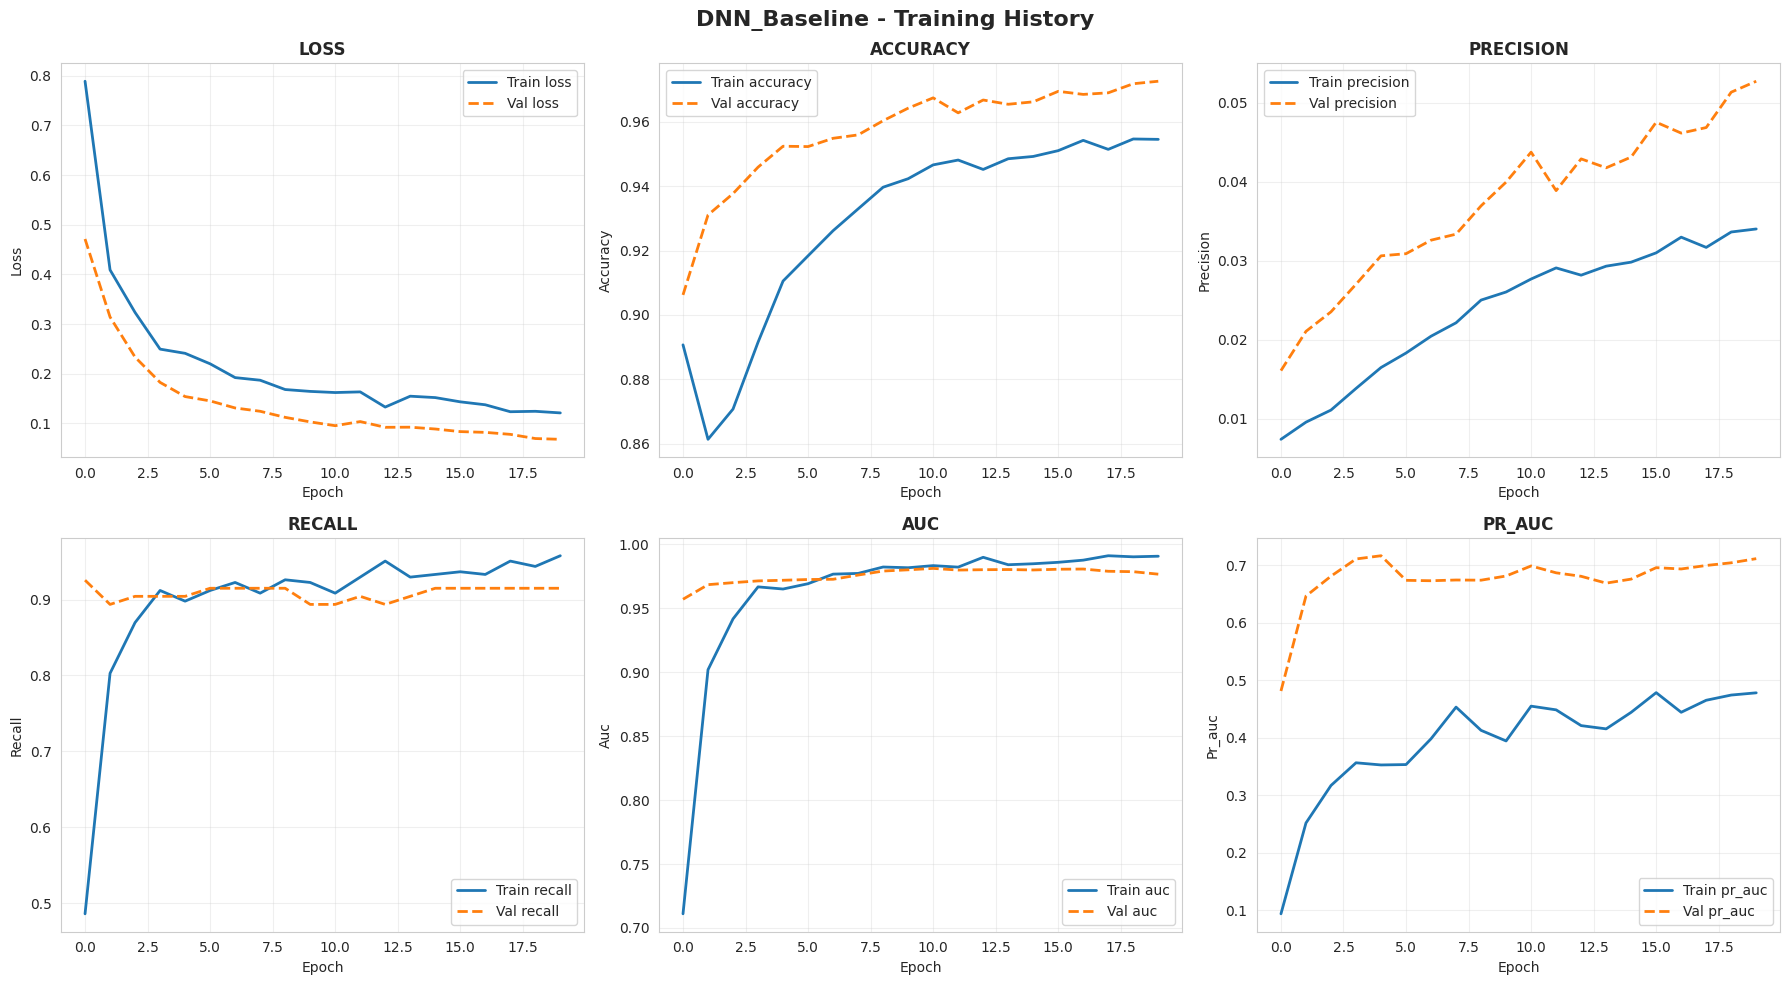

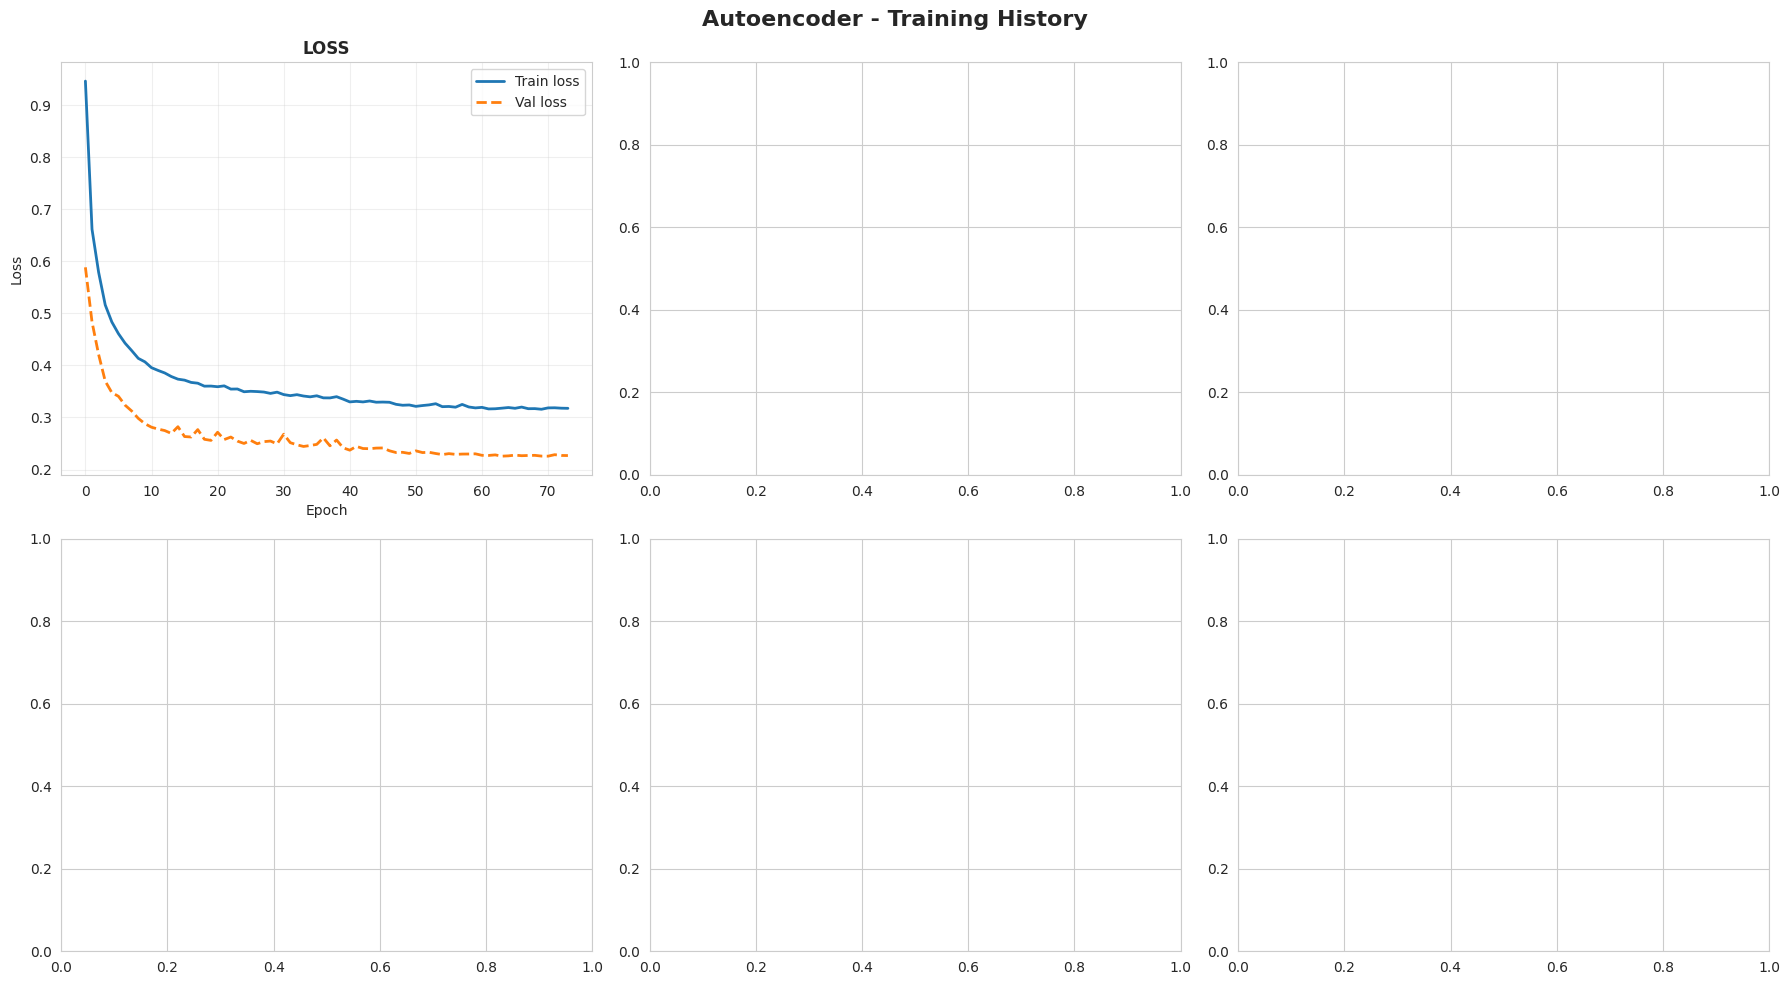

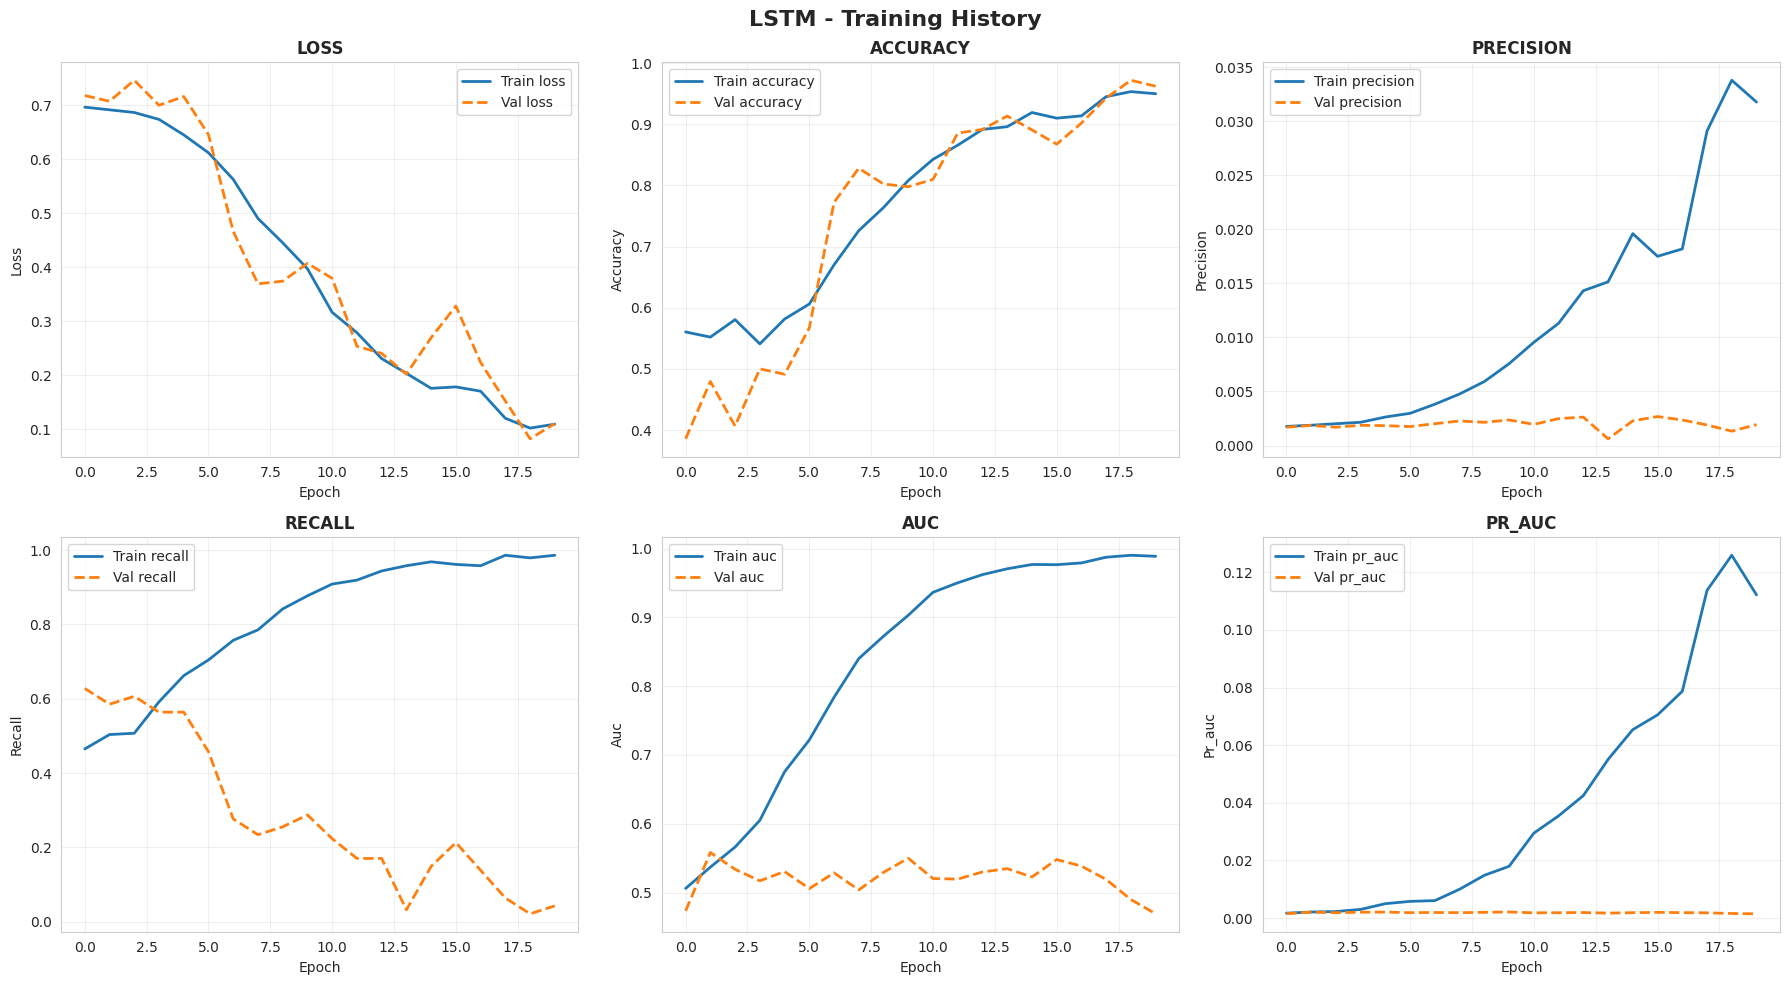

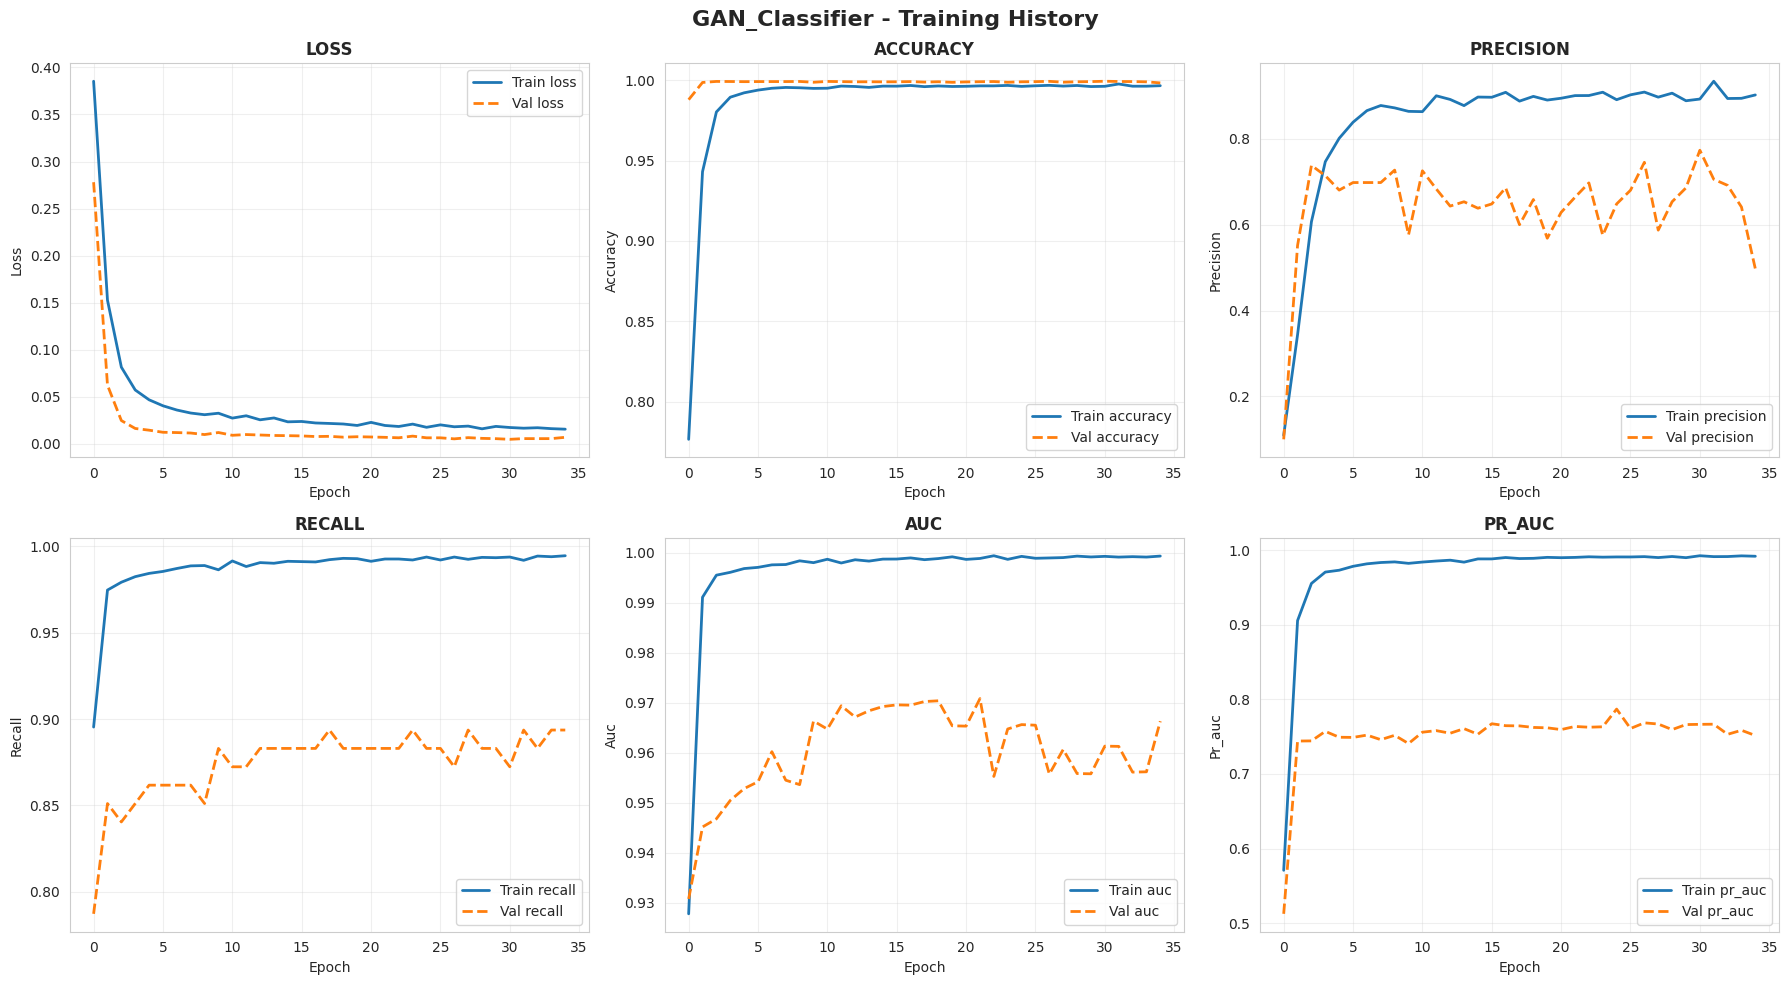

In [ ]:
# training history plots

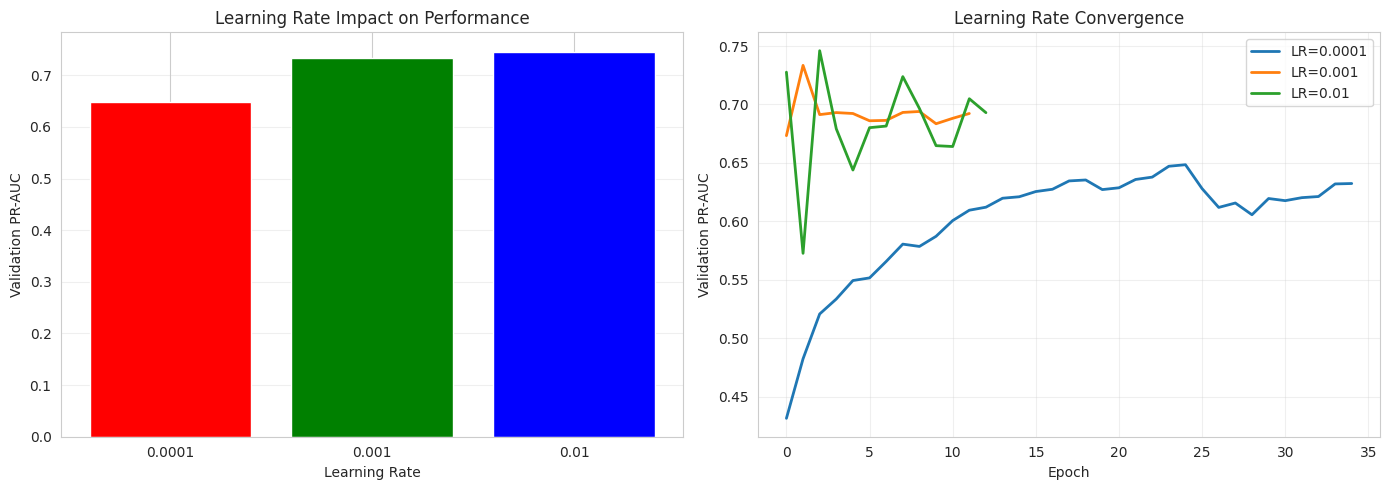

In [ ]:
# Plot learning rate effects
def plot_learning_rate_comparison(results_lr):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # PR-AUC comparison
    lrs = list(results_lr.keys())
    pr_aucs = [results_lr[lr]['val_pr_auc'] for lr in lrs]

    axes[0].bar(range(len(lrs)), pr_aucs, color=['red', 'green', 'blue'])
    axes[0].set_xticks(range(len(lrs)))
    axes[0].set_xticklabels(lrs)
    axes[0].set_xlabel('Learning Rate')
    axes[0].set_ylabel('Validation PR-AUC')
    axes[0].set_title('Learning Rate Impact on Performance')
    axes[0].grid(axis='y', alpha=0.3)

    # Training curves
    for lr in lrs:
        axes[1].plot(results_lr[lr]['history']['val_pr_auc'],
                    label=f'LR={lr}', linewidth=2)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Validation PR-AUC')
    axes[1].set_title('Learning Rate Convergence')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('learning_rate_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_learning_rate_comparison(results_lr)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


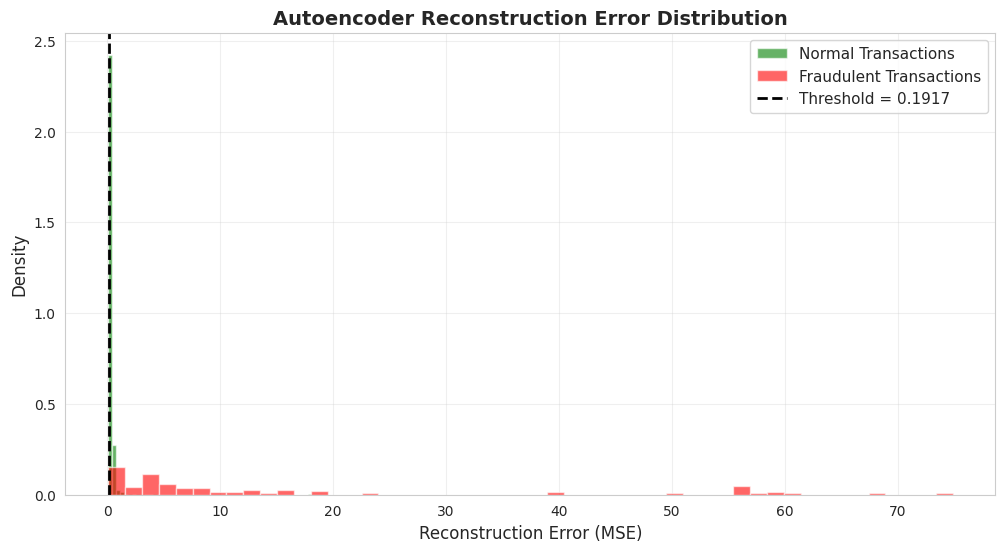

In [ ]:
# Plot autoencoder reconstruction error distribution
def plot_reconstruction_error(autoencoder, X_normal, X_fraud, threshold):

    # Calculate reconstruction errors
    normal_pred = autoencoder.predict(X_normal)
    fraud_pred = autoencoder.predict(X_fraud)

    normal_mse = np.mean(np.power(X_normal - normal_pred, 2), axis=1)
    fraud_mse = np.mean(np.power(X_fraud - fraud_pred, 2), axis=1)

    # Plot
    plt.figure(figsize=(12, 6))

    plt.hist(normal_mse, bins=50, alpha=0.6, label='Normal Transactions',
             color='green', density=True)
    plt.hist(fraud_mse, bins=50, alpha=0.6, label='Fraudulent Transactions',
             color='red', density=True)
    plt.axvline(threshold, color='black', linestyle='--', linewidth=2,
                label=f'Threshold = {threshold:.4f}')

    plt.xlabel('Reconstruction Error (MSE)', fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.title('Autoencoder Reconstruction Error Distribution',
              fontsize=14, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)

    plt.savefig('autoencoder_reconstruction_error.png', dpi=300, bbox_inches='tight')
    plt.show()

# Get fraud samples from test set
X_test_fraud = X_test[y_test == 1]
X_test_normal = X_test[y_test == 0]

plot_reconstruction_error(autoencoder, X_test_normal[:1000], X_test_fraud, threshold)

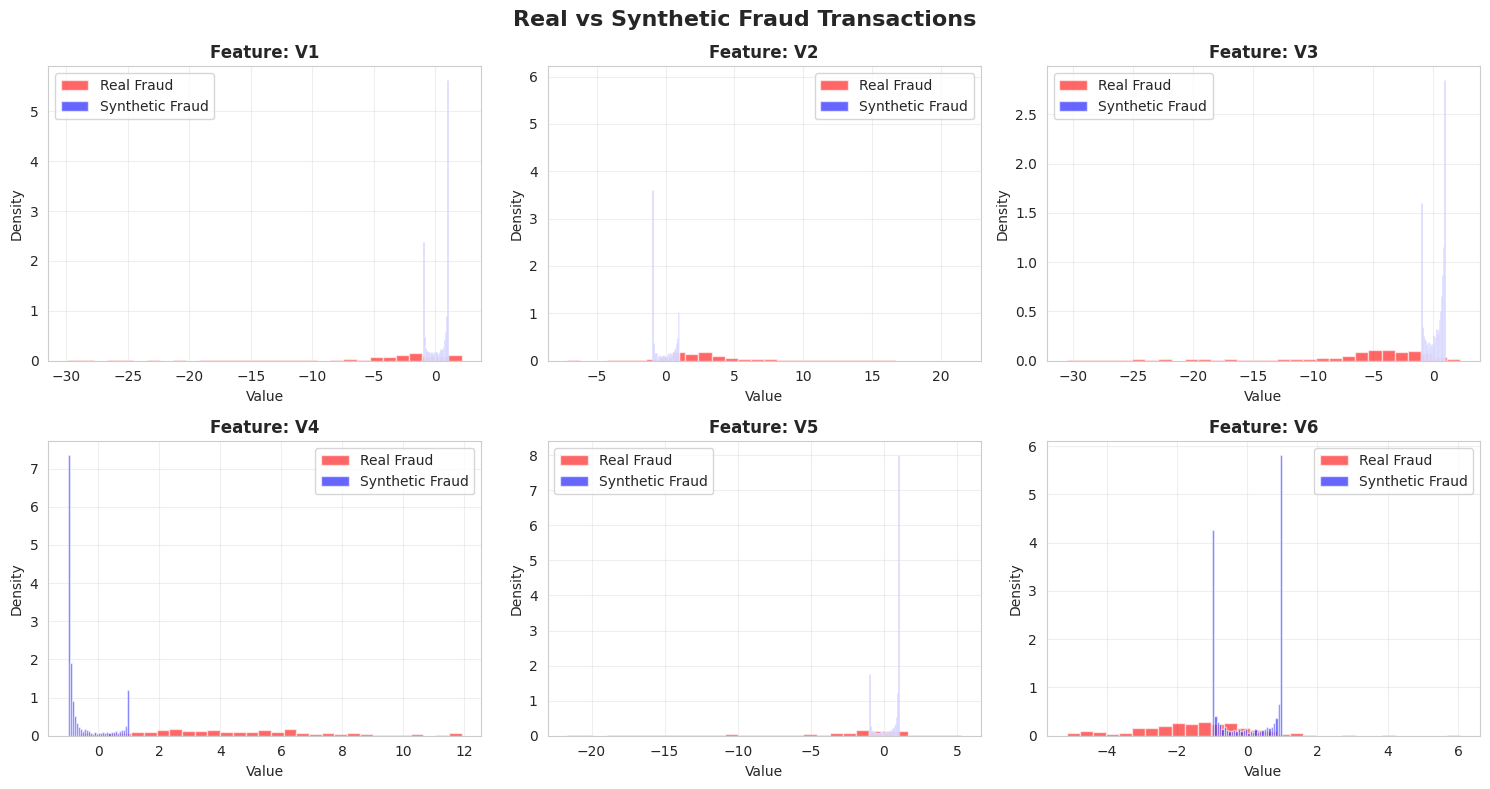

In [ ]:
# Plot GAN generated samples comparison
def plot_gan_samples(real_fraud, synthetic_fraud, feature_names):

    n_features = min(6, len(feature_names))
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle('Real vs Synthetic Fraud Transactions',
                 fontsize=16, fontweight='bold')

    for idx in range(n_features):
        ax = axes[idx // 3, idx % 3]

        ax.hist(real_fraud[:, idx], bins=30, alpha=0.6,
               label='Real Fraud', color='red', density=True)
        ax.hist(synthetic_fraud[:, idx], bins=30, alpha=0.6,
               label='Synthetic Fraud', color='blue', density=True)

        ax.set_title(f'Feature: {feature_names[idx]}', fontweight='bold')
        ax.set_xlabel('Value')
        ax.set_ylabel('Density')
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('gan_synthetic_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

feature_names = X_train.columns.tolist()
plot_gan_samples(X_fraud.values, synthetic_fraud, feature_names)

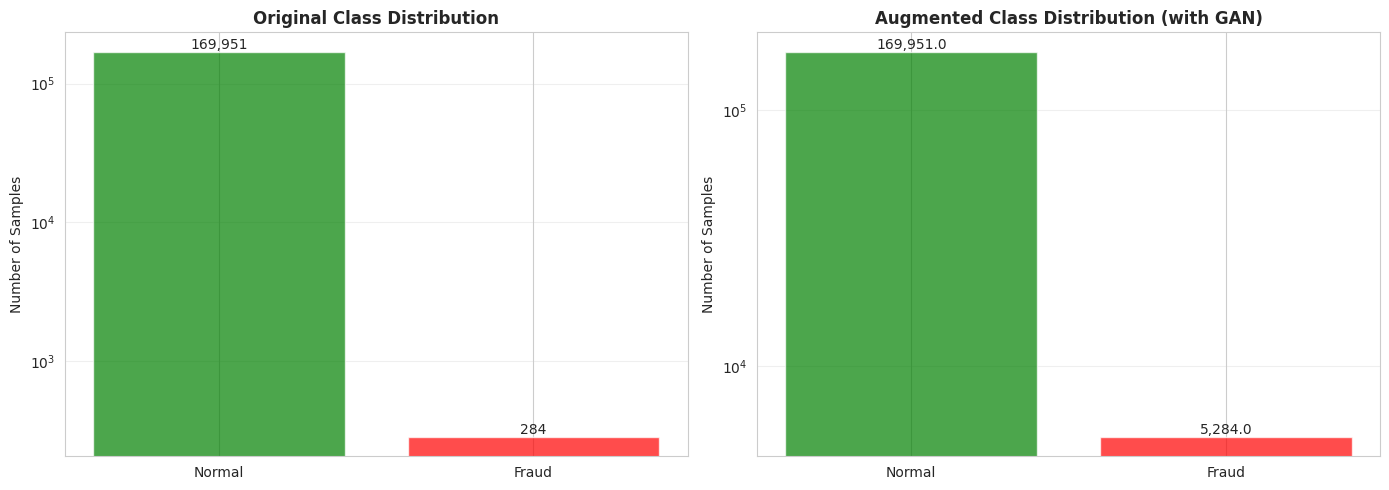

In [ ]:
# Plot class distribution before and after GAN augmentation
def plot_class_distribution():

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Original distribution
    original = [len(y_train) - y_train.sum(), y_train.sum()]
    colors = ['green', 'red']
    ax1.bar(['Normal', 'Fraud'], original, color=colors, alpha=0.7)
    ax1.set_ylabel('Number of Samples')
    ax1.set_title('Original Class Distribution', fontweight='bold')
    ax1.set_yscale('log')
    for i, v in enumerate(original):
        ax1.text(i, v, f'{v:,}', ha='center', va='bottom')
    ax1.grid(axis='y', alpha=0.3)

    # Augmented distribution
    augmented = [len(y_train_augmented) - y_train_augmented.sum(),
                 y_train_augmented.sum()]
    ax2.bar(['Normal', 'Fraud'], augmented, color=colors, alpha=0.7)
    ax2.set_ylabel('Number of Samples')
    ax2.set_title('Augmented Class Distribution (with GAN)', fontweight='bold')
    ax2.set_yscale('log')
    for i, v in enumerate(augmented):
        ax2.text(i, v, f'{v:,}', ha='center', va='bottom')
    ax2.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig('class_distribution_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_class_distribution()

In [ ]:
# MODEL EVALUATION ON TEST SET
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve,
    average_precision_score, f1_score
)

def evaluate_model(model, X_test, y_test, model_name, threshold=0.5):
    """Comprehensive model evaluation"""

    # Get predictions
    y_pred_proba = model.predict(X_test).ravel()
    y_pred = (y_pred_proba > threshold).astype(int)

    # Metrics
    print(f"\n{'-'*60}")
    print(f"{model_name} - Test Set Evaluation")
    print(f"{'-'*60}\n")

    # Classification report
    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['Normal', 'Fraud']))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    print(f"\nConfusion Matrix:")
    print(cm)

    # Calculate metrics
    tn, fp, fn, tp = cm.ravel()

    print(f"\nDetailed Metrics:")
    print(f"True Negatives:  {tn:,}")
    print(f"False Positives: {fp:,}")
    print(f"False Negatives: {fn}")
    print(f"True Positives:  {tp}")

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    print(f"\nPrecision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")

    # ROC-AUC
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    print(f"ROC-AUC:   {roc_auc:.4f}")

    # PR-AUC
    pr_auc = average_precision_score(y_test, y_pred_proba)
    print(f"PR-AUC:    {pr_auc:.4f}")

    return {
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba,
        'cm': cm,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'pr_auc': pr_auc,
        'fpr': fpr,
        'tpr': tpr
    }

# Evaluate all models
results = {}

# DNN
results['DNN'] = evaluate_model(dnn_model, X_test, y_test, 'DNN Baseline')

# Autoencoder
y_pred_ae = predict_autoencoder(X_test, threshold)
results['Autoencoder'] = {
    'y_pred': y_pred_ae,
    'cm': confusion_matrix(y_test, y_pred_ae)
}
print("\nAutoencoder Results:")
print(classification_report(y_test, y_pred_ae, target_names=['Normal', 'Fraud']))

# LSTM
results['LSTM'] = evaluate_model(lstm_model, X_test_seq, y_test_seq, 'LSTM')

# GAN Classifier
results['GAN_Classifier'] = evaluate_model(gan_classifier, X_test, y_test,
                                          'GAN + Classifier')

1774/1774 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step

------------------------------------------------------------
DNN Baseline - Test Set Evaluation
------------------------------------------------------------

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.95      0.97     56651
       Fraud       0.03      0.87      0.06        95

    accuracy                           0.95     56746
   macro avg       0.51      0.91      0.52     56746
weighted avg       1.00      0.95      0.97     56746


Confusion Matrix:
[[53885  2766]
 [   12    83]]

Detailed Metrics:
True Negatives:  53,885
False Positives: 2,766
False Negatives: 12
True Positives:  83

Precision: 0.0291
Recall:    0.8737
F1-Score:  0.0564
ROC-AUC:   0.9671
PR-AUC:    0.6279
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step

Autoencoder Results:
              precision    recall  f1-score   support

      Normal       1.00      0.68      0.81     56651
       Fraud       0.00    

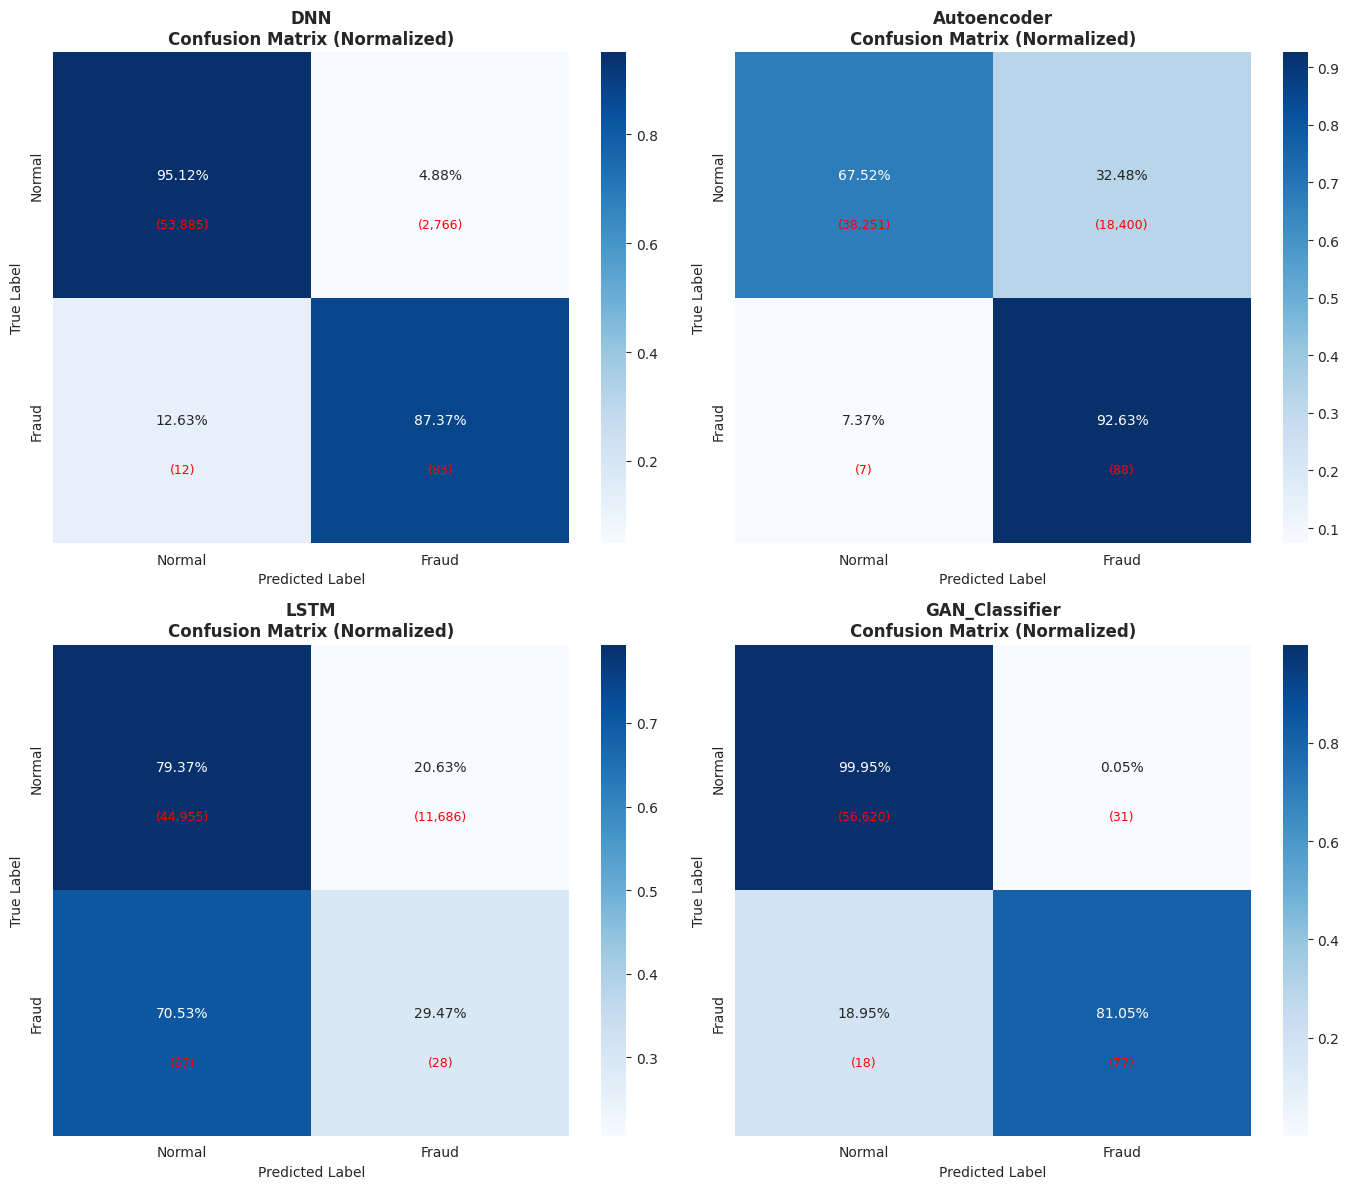

In [ ]:
# Visualization of Results
# Plot confusion matrices
def plot_confusion_matrices(results):

    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    models = ['DNN', 'Autoencoder', 'LSTM', 'GAN_Classifier']

    for idx, model_name in enumerate(models):
        ax = axes[idx // 2, idx % 2]

        cm = results[model_name]['cm']

        # Normalize
        cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

        # Plot
        sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
                   ax=ax, cbar=True,
                   xticklabels=['Normal', 'Fraud'],
                   yticklabels=['Normal', 'Fraud'])

        ax.set_title(f'{model_name}\nConfusion Matrix (Normalized)',
                    fontweight='bold', fontsize=12)
        ax.set_ylabel('True Label')
        ax.set_xlabel('Predicted Label')

        # Add counts
        for i in range(2):
            for j in range(2):
                ax.text(j+0.5, i+0.7, f'({cm[i,j]:,})',
                       ha='center', va='center', fontsize=9, color='red')

    plt.tight_layout()
    plt.savefig('confusion_matrices_all_models.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_confusion_matrices(results)

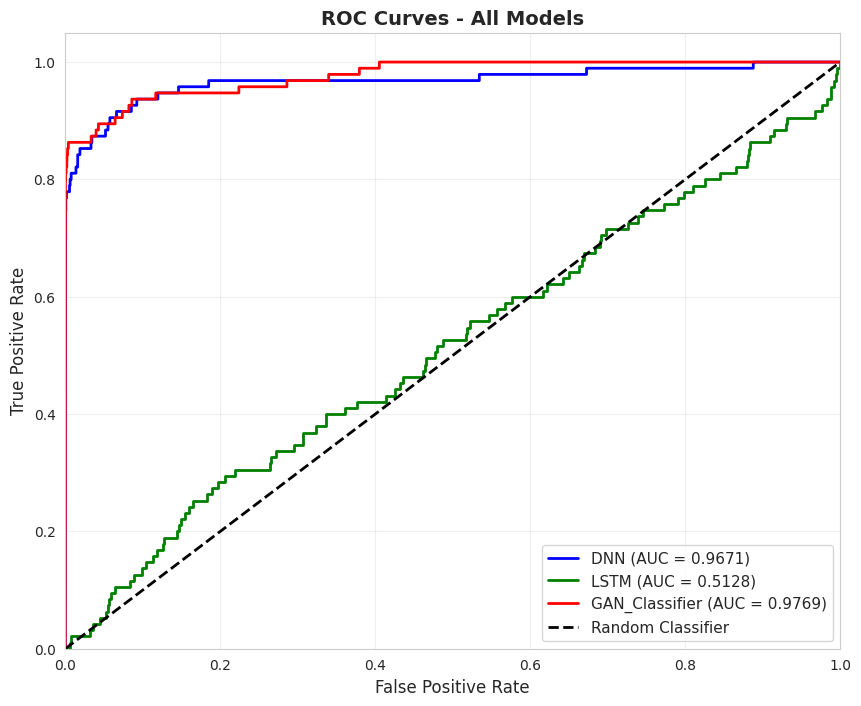

In [ ]:
# Plot ROC curves
def plot_roc_curves(results):

    plt.figure(figsize=(10, 8))

    models = ['DNN', 'LSTM', 'GAN_Classifier']
    colors = ['blue', 'green', 'red']

    for model_name, color in zip(models, colors):
        fpr = results[model_name]['fpr']
        tpr = results[model_name]['tpr']
        roc_auc = results[model_name]['roc_auc']

        plt.plot(fpr, tpr, color=color, linewidth=2,
                label=f'{model_name} (AUC = {roc_auc:.4f})')

    # Random classifier
    plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier')

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('ROC Curves - All Models', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right", fontsize=11)
    plt.grid(True, alpha=0.3)

    plt.savefig('roc_curves_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_roc_curves(results)

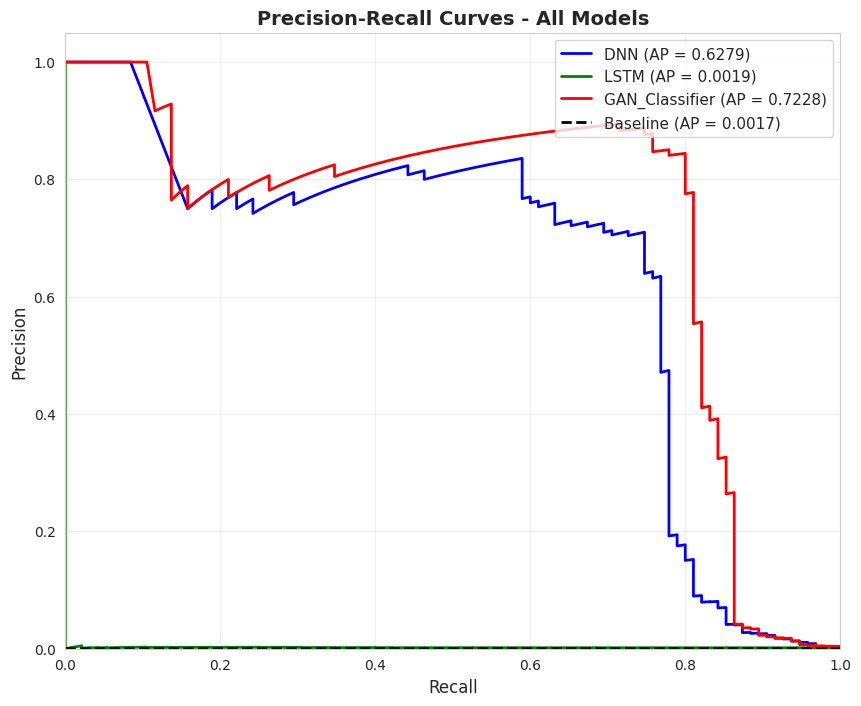

In [ ]:
# Plot Precision-Recall curves
def plot_pr_curves(results):

    plt.figure(figsize=(10, 8))

    models = ['DNN', 'LSTM', 'GAN_Classifier']
    colors = ['blue', 'green', 'red']

    for model_name, color in zip(models, colors):
        y_pred_proba = results[model_name]['y_pred_proba']

        # Determine the correct y_true for the current model
        if model_name == 'LSTM':
            current_y_true = y_test_seq # Use y_test_seq for LSTM
        else:
            current_y_true = y_test # Use global y_test for others

        precision, recall, _ = precision_recall_curve(current_y_true, y_pred_proba)
        pr_auc = results[model_name]['pr_auc']

        plt.plot(recall, precision, color=color, linewidth=2,
                label=f'{model_name} (AP = {pr_auc:.4f})')

    # Baseline (random classifier for imbalanced data)
    baseline = y_test.sum() / len(y_test) # Using global y_test for overall baseline
    plt.plot([0, 1], [baseline, baseline], 'k--', linewidth=2,
            label=f'Baseline (AP = {baseline:.4f})')

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Recall', fontsize=12)
    plt.ylabel('Precision', fontsize=12)
    plt.title('Precision-Recall Curves - All Models', fontsize=14, fontweight='bold')
    plt.legend(loc="upper right", fontsize=11)
    plt.grid(True, alpha=0.3)

    plt.savefig('pr_curves_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_pr_curves(results)

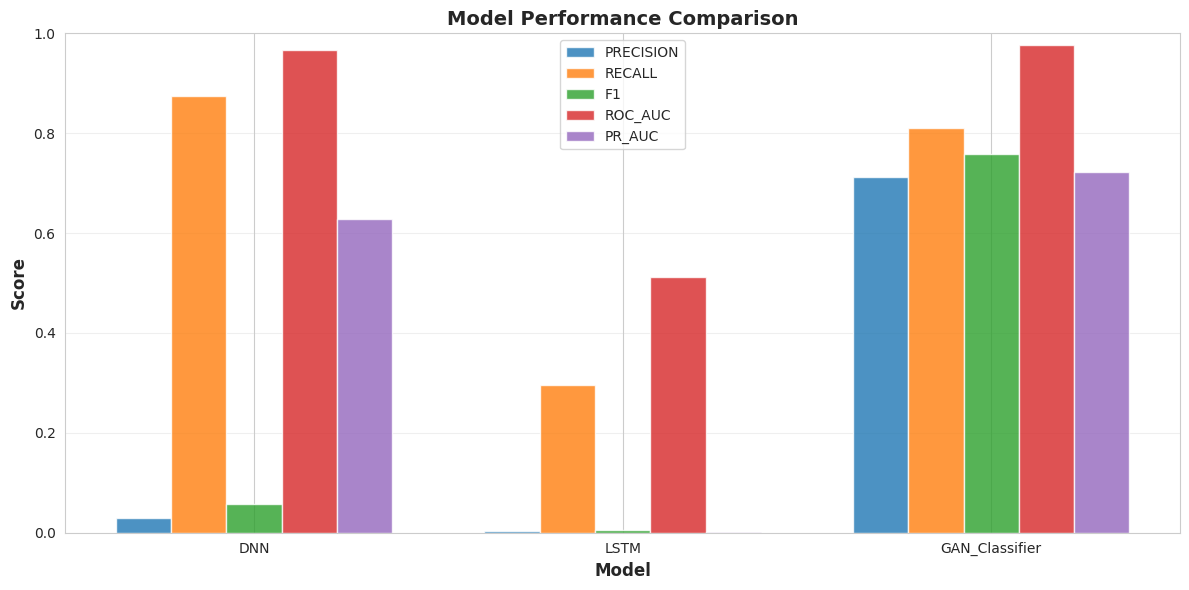

In [ ]:
# Comparison bar chart
def plot_metrics_comparison(results):

    models = ['DNN', 'LSTM', 'GAN_Classifier']
    metrics = ['precision', 'recall', 'f1', 'roc_auc', 'pr_auc']

    data = {metric: [results[model][metric] for model in models]
            for metric in metrics}

    x = np.arange(len(models))
    width = 0.15

    fig, ax = plt.subplots(figsize=(12, 6))

    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

    for idx, (metric, color) in enumerate(zip(metrics, colors)):
        offset = width * (idx - 2)
        ax.bar(x + offset, data[metric], width, label=metric.upper(),
              color=color, alpha=0.8)

    ax.set_xlabel('Model', fontsize=12, fontweight='bold')
    ax.set_ylabel('Score', fontsize=12, fontweight='bold')
    ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim([0, 1.0])

    plt.tight_layout()
    plt.savefig('metrics_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_metrics_comparison(results)

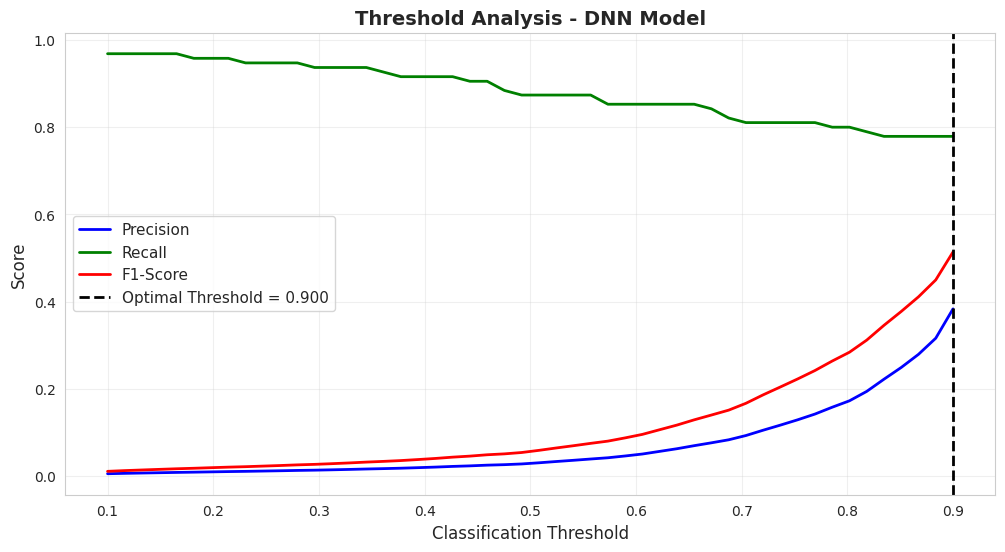

Optimal threshold: 0.9000


In [ ]:
# Threshold analysis for DNN
def plot_threshold_analysis(y_test, y_pred_proba):

    thresholds = np.linspace(0.1, 0.9, 50)
    precisions = []
    recalls = []
    f1_scores = []

    for thresh in thresholds:
        y_pred = (y_pred_proba > thresh).astype(int)

        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

        precisions.append(precision)
        recalls.append(recall)
        f1_scores.append(f1)

    # Plot
    plt.figure(figsize=(12, 6))

    plt.plot(thresholds, precisions, label='Precision', linewidth=2, color='blue')
    plt.plot(thresholds, recalls, label='Recall', linewidth=2, color='green')
    plt.plot(thresholds, f1_scores, label='F1-Score', linewidth=2, color='red')

    # Find optimal threshold (max F1)
    optimal_idx = np.argmax(f1_scores)
    optimal_threshold = thresholds[optimal_idx]

    plt.axvline(optimal_threshold, color='black', linestyle='--', linewidth=2,
               label=f'Optimal Threshold = {optimal_threshold:.3f}')

    plt.xlabel('Classification Threshold', fontsize=12)
    plt.ylabel('Score', fontsize=12)
    plt.title('Threshold Analysis - DNN Model', fontsize=14, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)

    plt.savefig('threshold_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

    return optimal_threshold

optimal_threshold = plot_threshold_analysis(y_test, results['DNN']['y_pred_proba'])
print(f"Optimal threshold: {optimal_threshold:.4f}")

1774/1774 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step

DNN - Error Analysis
Total frauds: 95
Caught frauds: 83 (87.4%)
Missed frauds: 12 (12.6%)


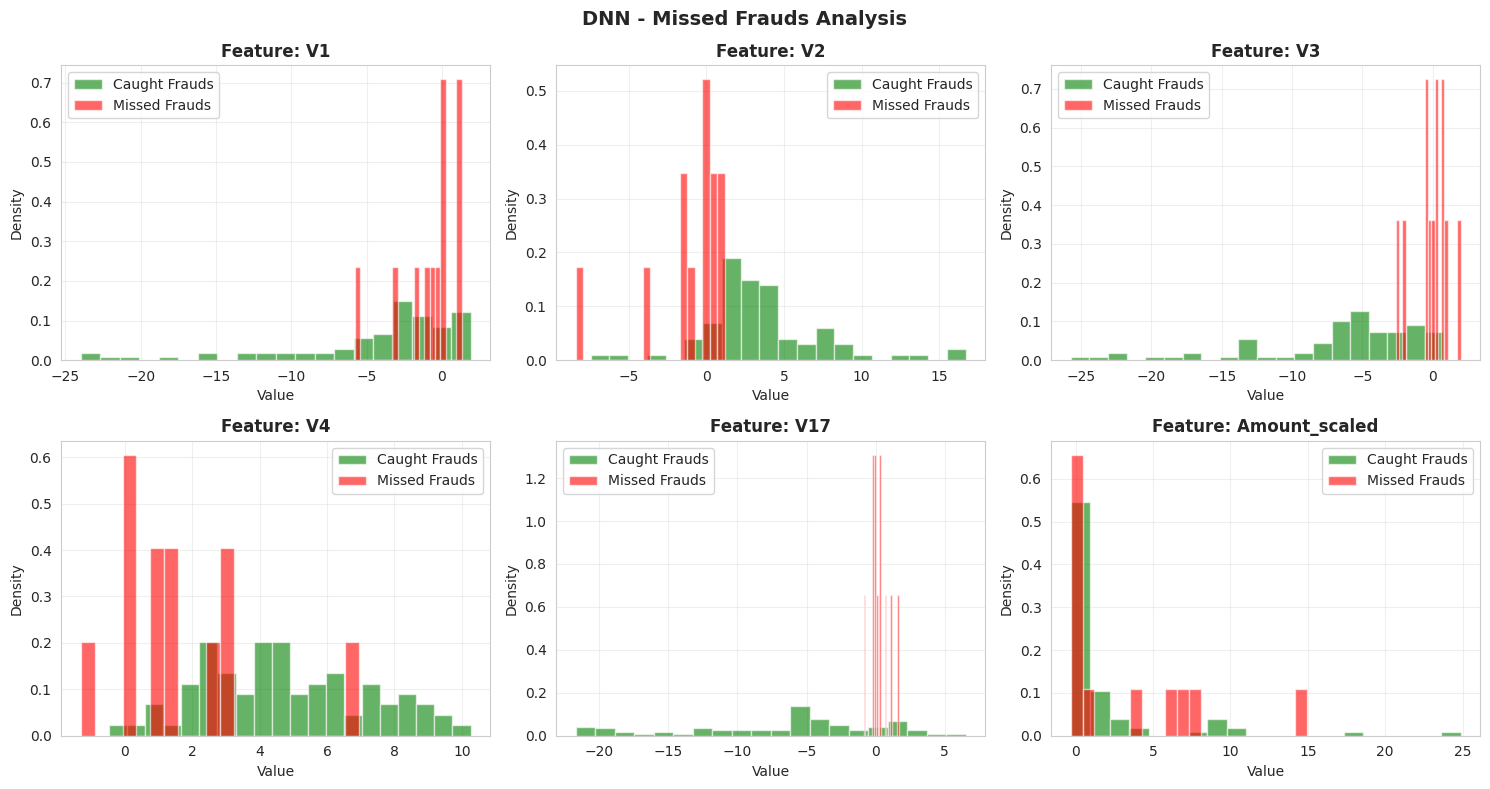

In [ ]:
# Error analysis - what frauds are we missing?
def analyze_errors(model, X_test, y_test, model_name):

    y_pred = (model.predict(X_test).ravel() > 0.5).astype(int)

    # False negatives (missed frauds)
    fn_mask = (y_test == 1) & (y_pred == 0)
    false_negatives = X_test[fn_mask]

    # True positives (caught frauds)
    tp_mask = (y_test == 1) & (y_pred == 1)
    true_positives = X_test[tp_mask]

    print(f"\n{model_name} - Error Analysis")
    print(f"Total frauds: {y_test.sum()}")
    print(f"Caught frauds: {tp_mask.sum()} ({tp_mask.sum()/y_test.sum()*100:.1f}%)")
    print(f"Missed frauds: {fn_mask.sum()} ({fn_mask.sum()/y_test.sum()*100:.1f}%)")

    # Compare feature distributions
    if len(false_negatives) > 0 and len(true_positives) > 0:
        fig, axes = plt.subplots(2, 3, figsize=(15, 8))
        fig.suptitle(f'{model_name} - Missed Frauds Analysis',
                    fontsize=14, fontweight='bold')

        features_to_plot = ['V1', 'V2', 'V3', 'V4', 'V17', 'Amount_scaled']

        for idx, feature in enumerate(features_to_plot):
            ax = axes[idx // 3, idx % 3]

            ax.hist(true_positives[feature], bins=20, alpha=0.6,
                   label='Caught Frauds', color='green', density=True)
            ax.hist(false_negatives[feature], bins=20, alpha=0.6,
                   label='Missed Frauds', color='red', density=True)

            ax.set_title(f'Feature: {feature}', fontweight='bold')
            ax.set_xlabel('Value')
            ax.set_ylabel('Density')
            ax.legend()
            ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig(f'{model_name}_error_analysis.png', dpi=300, bbox_inches='tight')
        plt.show()

analyze_errors(dnn_model, X_test, y_test, 'DNN')